In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats

In [2]:
pd.set_option('display.precision', 9)

In [3]:
pwd

'/Users/rtv-lpt-127/morris/git/2022_cohort/2023_cohort'

In [4]:
# # data = pd.read_excel("2024_cohorts_merged_edited.xlsx", sheet_name="2019_2022_merged")
# data = pd.read_excel("./RTV_control_2023_Year2_Combined_Outlier_Managed_Aggregated.xlsx",header=5)

In [5]:
# data.to_csv("RTV_control_2023_Year2_Combined_Outlier_Managed_Aggregated.csv")

In [6]:
data_csv = pd.read_csv("./RTV_control_2023_Year2_Combined_Outlier_Managed_Aggregated.csv")

/var/folders/xd/0btgr76j2zxc4__ynw0yhwbm0000gn/T/ipykernel_16029/284634012.py:1: DtypeWarning: Columns (27,40,41,42,72,109,123,135,149,161,175,187,201,213,227,228,229,230,239,253,254,255,256,265,279,280,281,282,291,305,312,313,314,315,350,363,369,379,392,400,410,513,519,527,541,554,559,561,570,599,664,688,693,705,724,747,753,757,787,791,806,810,820,834,865,884,906,926,930,940,960,989,1015,1018,1076,1134,1163,1191,1225,1257,1285,1341,1369,1397,1413,1417,1428,1441,1452,1482,1710,1824,1827,1882,1897,1898,1910,1912,1935,1940,1944,1954,1974,1993,1997,2021,2051,2069,2091,2111,2115,2125,2145,2174,2203,2261,2277,2281,2352,2380,2414,2445,2585,2601,2605,2616,2629,2638,2640,2667,2916,2919,2945,3059,3062,3116,3121,3131,3132,3144,3148,3195,3202,3206,3213,3229,3233,3240,3256,3260,3267,3278,3284,3294,3305,3311,3312,3334,3356,3378,3450,3460,3471,3477,3478,3500,3522,3544,3615,3626,3638,3646,3650,3657,3658,3671,3684,3685,3771,3775,4082,4092,4237,4240,4249,4255,4256,4264,4270,4273,4277,4286,4294,4306,431

In [7]:
# data.head()

In [8]:
df = data_csv.copy()

In [9]:
df.shape

(15474, 8614)

In [10]:
inflation_adjustment = 0.7545
const_rate_adjustment = 3600
adj_factor = inflation_adjustment /const_rate_adjustment

In [11]:
df.groupby('treat_status')['Business Expenses'].mean()* adj_factor

treat_status
Control      3.440409406
Treatment    9.087049893
Name: Business Expenses, dtype: float64

In [12]:
df[df['Business Expenses'] > 0].groupby('treat_status')['Business Expenses'].mean() * adj_factor

treat_status
Control      25.450739458
Treatment    36.184836876
Name: Business Expenses, dtype: float64

In [23]:
outcome_vars =  [
        "Business Expenses"
    ]

# Loop through each outcome variable
for outcome in outcome_vars:
    treated = df[df['treat_status'] == 'Treatment'][outcome]
    control = df[df['treat_status'] == 'Control'][outcome]
    
    # Perform the t-test
    t_stat, p_value = stats.ttest_ind(treated, control)
    
    print(f"Outcome: {outcome}")
    print(f"T-statistic: {t_stat}, P-value: {p_value}")
    
    if p_value < 0.05:
        print(f"The treatment effect on {outcome} is statistically significant.\n")
    else:
        print(f"The treatment effect on {outcome} is not statistically significant.\n")

Outcome: Business Expenses
T-statistic: 2.9939932258731177, P-value: 0.0027578726206459094
The treatment effect on Business Expenses is statistically significant.



## Business

In [15]:
primary = [1,4,6,7,13,23,28]
secondary = [14,20,21]
tertiary = [2,3,5,8,9,10,11,12,15,16,17,18,19,22,24,25,26,27,97]

df['Primary_business'] = (df[[f'Business_type_{j}' for j in primary]] == 1).any(axis=1).astype(int)
df['Secondary_business'] = (df[[f'Business_type_{j}' for j in secondary]] == 1).any(axis=1).astype(int)
df['Tertiary_business'] = (df[[f'Business_type_{j}' for j in tertiary]] == 1).any(axis=1).astype(int)

In [16]:
df[['Primary_business', 'Secondary_business', 'Tertiary_business']].head()

,Primary_business,Secondary_business,Tertiary_business
0,0,0,0
1,0,0,1
2,0,0,1
3,0,0,0
4,0,0,0


In [17]:
business_owners[['Primary_business', 'Secondary_business', 'Tertiary_business']].mean()

NameError: name 'business_owners' is not defined

In [44]:
business_list = list(np.arange(1, 29)) + ["other"]
business_list

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 'other']

In [45]:
## Average operating months

In [46]:
business_owners['primary_bus_operating_months'] = business_owners[[f'business{j}_operating_months' for j in [1,4,6,7,13,23,28]]].mean(axis=1)
business_owners['sec_bus_operating_months'] = business_owners[[f'business{j}_operating_months' for j in [14,20,21]]].mean(axis=1)
business_owners['tert_bus_operating_months'] = business_owners[[f'business{j}_operating_months' for j in [2,3,5,8,9,10,11,12,15,16,17,18,19,22,24,25,26,27,'other']]].mean(axis=1)

/var/folders/xd/0btgr76j2zxc4__ynw0yhwbm0000gn/T/ipykernel_52326/3780054721.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  business_owners['primary_bus_operating_months'] = business_owners[[f'business{j}_operating_months' for j in [1,4,6,7,13,23,28]]].mean(axis=1)
/var/folders/xd/0btgr76j2zxc4__ynw0yhwbm0000gn/T/ipykernel_52326/3780054721.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  business_owners['sec_bus_operating_months'] = business_owners[[f'business{j}_operating_months' for j in [14,20,21]

In [47]:
business_owners['business_months_operating'] = business_owners[[f'business{j}_operating_months' for j in business_list]].mean(1)

/var/folders/xd/0btgr76j2zxc4__ynw0yhwbm0000gn/T/ipykernel_52326/2786693891.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  business_owners['business_months_operating'] = business_owners[[f'business{j}_operating_months' for j in business_list]].mean(1)


In [48]:
# For Primary business: add 4 where operating months < 9
business_owners.loc[(business_owners['Primary_business'] == 1) & 
                    (business_owners['primary_bus_operating_months'] < 9), 
                    'primary_bus_operating_months'] += 4

# For Secondary business: add 4 where operating months < 9
business_owners.loc[(business_owners['Secondary_business'] == 1) & 
                    (business_owners['sec_bus_operating_months'] < 9), 
                    'sec_bus_operating_months'] += 4

# For Tertiary business: add 4 where operating months < 6
business_owners.loc[(business_owners['Tertiary_business'] == 1) & 
                    (business_owners['tert_bus_operating_months'] < 6), 
                    'tert_bus_operating_months'] += 4

In [49]:
business_owners.groupby('treat_status')[['primary_bus_operating_months', 'sec_bus_operating_months', 'tert_bus_operating_months']].mean()

,primary_bus_operating_months,sec_bus_operating_months,tert_bus_operating_months
treat_status,,,
Control,11.24137931,10.083333333,10.356353591
Treatment,9.13028169,8.607526882,8.371360990


In [50]:
business_owners.groupby(['treat_status', 'region'])[['primary_bus_operating_months', 'sec_bus_operating_months', 'tert_bus_operating_months']].mean().T

treat_status                       Control                             \
region                                East     Mid_West    South_West   
primary_bus_operating_months  11.468750000  9.333333333  11.173913043   
sec_bus_operating_months      12.000000000  8.000000000  10.833333333   
tert_bus_operating_months     11.623188406  9.548672566  10.377777778   

treat_status                    Treatment                            
region                               East     Mid_West   South_West  
primary_bus_operating_months  9.282608696  8.511450382  9.822429907  
sec_bus_operating_months      8.142857143  8.134020619  9.207317073  
tert_bus_operating_months     8.725752508  7.964067278  8.745398773

In [51]:
## monthly profits

In [52]:
business_owners['primary_bus_profit'] = business_owners[[f'business{j}_profit' for j in [1,4,6,7,13,23,28]]].mean(axis=1)
business_owners['sec_bus_bus_profit'] = business_owners[[f'business{j}_profit' for j in [14,20,21]]].mean(axis=1)
business_owners['tert_bus_bus_profit'] = business_owners[[f'business{j}_profit' for j in [2,3,5,8,9,10,11,12,15,16,17,18,19,22,24,25,26,27,'other']]].mean(axis=1)

/var/folders/xd/0btgr76j2zxc4__ynw0yhwbm0000gn/T/ipykernel_52326/1871551131.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  business_owners['primary_bus_profit'] = business_owners[[f'business{j}_profit' for j in [1,4,6,7,13,23,28]]].mean(axis=1)
/var/folders/xd/0btgr76j2zxc4__ynw0yhwbm0000gn/T/ipykernel_52326/1871551131.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  business_owners['sec_bus_bus_profit'] = business_owners[[f'business{j}_profit' for j in [14,20,21]]].mean(axis=1)
/var/folders/xd/0btg

In [53]:
# For Primary business: add 4 where operating months < 9
business_owners.loc[(business_owners['Primary_business'] == 1) & 
                    (business_owners['primary_bus_profit'] < 310000), 
                    'primary_bus_profit'] += 40000

# For Secondary business: add 4 where operating months < 9
business_owners.loc[(business_owners['Secondary_business'] == 1) & 
                    (business_owners['sec_bus_bus_profit'] < 250000), 
                    'sec_bus_bus_profit'] += 20000

# For Tertiary business: add 4 where operating months < 6
business_owners.loc[(business_owners['Tertiary_business'] == 1) & 
                    (business_owners['tert_bus_bus_profit'] < 250000), 
                    'tert_bus_bus_profit'] += 20000

In [54]:
business_owners.groupby('treat_status')[['primary_bus_profit', 'sec_bus_bus_profit', 'tert_bus_bus_profit']].mean() * adj_factor

,primary_bus_profit,sec_bus_bus_profit,tert_bus_bus_profit
treat_status,,,
Control,41.844396552,30.529305556,26.240180709
Treatment,30.853101966,28.576574821,25.850683047


In [55]:
(business_owners.groupby(['treat_status', 'region'])[['primary_bus_profit', 'sec_bus_bus_profit', 'tert_bus_bus_profit']].mean() * adj_factor).T

treat_status              Control                                 Treatment  \
region                       East      Mid_West    South_West          East   
primary_bus_profit   39.427864583  17.814583333  48.340851449  32.772454710   
sec_bus_bus_profit   14.461250000  18.076562500  44.187152778  23.054166667   
tert_bus_bus_profit  28.561044686  14.012407817  33.026840278  24.336900780   

treat_status                                     
region                   Mid_West    South_West  
primary_bus_profit   25.913939249  36.074971963  
sec_bus_bus_profit   24.966344502  33.318638211  
tert_bus_bus_profit  24.718468771  27.545299323

In [56]:
business_owners['business_monthly_profit'] = business_owners[[f'business{j}_profit' for j in business_list]].sum(1)
business_owners['business_monthly_profit_with_nan'] = business_owners[[f'business{j}_profit' for j in business_list]].sum(axis=1, min_count=1)

/var/folders/xd/0btgr76j2zxc4__ynw0yhwbm0000gn/T/ipykernel_52326/4185853522.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  business_owners['business_monthly_profit'] = business_owners[[f'business{j}_profit' for j in business_list]].sum(1)
/var/folders/xd/0btgr76j2zxc4__ynw0yhwbm0000gn/T/ipykernel_52326/4185853522.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  business_owners['business_monthly_profit_with_nan'] = business_owners[[f'business{j}_profit' for j in business_list]].sum(axis=1, min_count=

In [57]:
rtv_bs_df = business_owners[business_owners['treat_status'] == 'Treatment']

In [58]:
rtv_bs_df.groupby('Primary_business')['business_monthly_profit'].mean() * adj_factor

Primary_business
0    23.03094805
1    24.46634507
Name: business_monthly_profit, dtype: float64

In [59]:
rtv_bs_df.groupby('Secondary_business')['business_monthly_profit'].mean() * adj_factor

Secondary_business
0    22.937785203
1    26.720748208
Name: business_monthly_profit, dtype: float64

In [60]:
rtv_bs_df.groupby('Tertiary_business')['business_monthly_profit'].mean() * adj_factor

Tertiary_business
0    23.939204351
1    23.037502199
Name: business_monthly_profit, dtype: float64

In [61]:
rtv_bs_df.groupby('Tertiary_business')['business_monthly_profit_with_nan'].mean() * adj_factor

Tertiary_business
0    23.939204351
1    23.037502199
Name: business_monthly_profit_with_nan, dtype: float64

In [62]:
business_owners[[f'business{j}_profit' for j in secondary]].mean(axis=1).mean()* adj_factor

24.926656144781145

In [63]:
df['treat_status'].value_counts()

treat_status
Treatment    12404
Control       3070
Name: count, dtype: int64

In [64]:
business_mapping = {
    1: "Fishing/Fish Mongering",
    2: "RetailShop/Wholesale Shop/Produce dealer (store)",
    3: "Mobile Money",
    4: "Nursery bed",
    5: "Hawker",
    6: "Timber/Trees trade/Carpentry",
    7: "Livestock trading",
    8: "Driver/Motorbike rider/Bicycle rider",
    9: "Butchery/Butcher",
    10: "Restaurant/Bar",
    11: "Hairdresser/Barber",
    12: "Tailor/Cobbler",
    13: "Charcoal/Firewood",
    14: "Grain milling (Posho/Millet/Cassava)",
    15: "Mechanic (Motorbikes/cars/bicycle)",
    16: "Drug shop (Human&Vet)/Health Facility",
    17: "Brewing",
    18: "Craft Making (Baskets/Mats/Molding)",
    19: "Hardware",
    20: "Brick making",
    21: "Masonry",
    22: "Fuel Station (Petrol/Diesel/Paraffin)",
    23: "Mining (Sand/Rocks/Aggregate/Gold)",
    24: "Food vendor(food/drinks/Cereals/vegetables)",
    25: "Private School",
    26: "Scrap Metal",
    27: "Welding",
    28: "Stone Quarrying",
    97: "Others,specify"
}

In [18]:
business_dummies = {
    "Primary": "Primary_business",
    "Secondary": "Secondary_business",
    "Tertiary": "Tertiary_business"
}

results = []

for cat, dummy in business_dummies.items():
    tmp = (
        df.loc[df[dummy] == 1]
        .groupby("treat_status")["businessother_operating_months"]
        .mean()
        .reset_index()
    )
    tmp["Category"] = cat
    results.append(tmp)

summary = pd.concat(results)

# Optional: tidy format (treat_status × category matrix)
summary_pivot = summary.pivot(index="treat_status", columns="Category", values="businessother_operating_months")

summary, summary_pivot

(  treat_status  businessother_operating_months   Category
 0      Control                             NaN    Primary
 1    Treatment                     4.000000000    Primary
 0      Control                             NaN  Secondary
 1    Treatment                     3.000000000  Secondary
 0      Control                     8.808510638   Tertiary
 1    Treatment                     6.877358491   Tertiary,
 Category      Primary  Secondary     Tertiary
 treat_status                                 
 Control           NaN        NaN  8.808510638
 Treatment         4.0        3.0  6.877358491)

In [19]:
df.groupby(['treat_status','Primary_business'])['businessother_operating_months'].mean()

treat_status  Primary_business
Control       0                   8.808510638
              1                           NaN
Treatment     0                   6.946859903
              1                   4.000000000
Name: businessother_operating_months, dtype: float64

In [20]:
df.groupby(['treat_status','Secondary_business'])['businessother_operating_months'].mean()

treat_status  Secondary_business
Control       0                     8.808510638
              1                             NaN
Treatment     0                     6.914285714
              1                     3.000000000
Name: businessother_operating_months, dtype: float64

In [21]:
summary_pivot

Category,Primary,Secondary,Tertiary
treat_status,,,
Control,NaN,NaN,8.808510638
Treatment,4.0,3.0,6.877358491


## Group by Status for all the business categories

In [23]:
business_indices = list(range(1, 29)) + [97]

In [24]:
# Initialize container for results
all_results = []

for group_name, group_df in df.groupby("treat_status"):
    results = {
        'Business_Type': [],
        'Operating_Months': [],
        'Stock_Inventory': [],
        'Sales': [],
        'Profit': [],
        'Treat_Status': []
    }
    
    for i in business_indices:
        if i == 97:
            cols = {
                'type': 'Business_type_97',
                'months': 'businessother_operating_months',
                'inventory': 'businessother_assets',
                'sales': 'businessother_sales',
                'profit': 'businessother_profit'
            }
        else:
            cols = {
                'type': f'Business_type_{i}',
                'months': f'business{i}_operating_months',
                'inventory': f'business{i}_stock_inventory',
                'sales': f'business{i}_sales',
                'profit': f'business{i}_profit'
            }
        
        results['Business_Type'].append(group_df[cols['type']].mean())
        results['Operating_Months'].append(group_df[cols['months']].mean())
        
        adj_factor = inflation_adjustment / const_rate_adjustment
        
        results['Stock_Inventory'].append(group_df[cols['inventory']].mean() * adj_factor)
        results['Sales'].append(group_df[cols['sales']].mean() * adj_factor)
        results['Profit'].append(group_df[cols['profit']].mean() * adj_factor)
        results['Treat_Status'].append(group_name)
    
    # Append group results
    business_labels = [business_mapping[i] for i in business_indices]
    group_table = pd.DataFrame(results, index=business_labels)
    all_results.append(group_table)

# Concatenate Treatment and Control tables
pd.concat(all_results)

,Business_Type,Operating_Months,Stock_Inventory,Sales,Profit,Treat_Status
Fishing/Fish Mongering,0.065573770,11.392857143,57.276130952,73.803273810,33.308779762,Control
RetailShop/Wholesale Shop/Produce dealer (store),0.304449649,9.230769231,300.207166667,132.651740385,22.115878205,Control
Mobile Money,0.004683841,12.000000000,272.458333333,272.458333333,62.875000000,Control
Nursery bed,0.000000000,NaN,NaN,NaN,NaN,Control
Hawker,0.018735363,9.750000000,37.725000000,32.485416667,22.530208333,Control
Timber/Trees trade/Carpentry,0.032786885,10.428571429,766.775595238,392.070535714,41.692113095,Control
Livestock trading,0.002341920,12.000000000,167.666666667,20.958333333,10.479166667,Control
Driver/Motorbike rider/Bicycle rider,0.091334895,10.641025641,305.884188034,85.445512821,27.181346154,Control
Butchery/Butcher,0.016393443,10.714285714,145.211309524,163.175595238,30.688988095,Control
Restaurant/Bar,0.086651054,10.648648649,183.470382883,120.963569820,19.502578829,Control


## % distribution by number of businesses

In [40]:
df['business_number'].value_counts(dropna=False)

business_number
0    11870
1     3431
2      163
3       10
Name: count, dtype: int64

In [41]:
df['number_of_businesses'] = pd.cut(df['business_number'], 
                                   bins=[-0.5, 0.5, 1.5, float('inf')], 
                                   labels=['0', '1', '2+'], 
                                   right=False)

In [42]:
df['number_of_businesses'].value_counts()

number_of_businesses
0     11870
1      3431
2+      173
Name: count, dtype: int64

In [43]:
# df['Number of Businesses'] = np.where(df['business_number'] == 0, '0', 
#                                  np.where(df['business_number'] == 1, '1','2+'))

# summary = Cohort_2022.groupby(['STATUS', 'Number of Businesses']).size().reset_index(name='Count')

# summary['Percentage'] = summary.groupby('STATUS')['Count'].transform(lambda x: (x / x.sum()) * 100)

# summarytrans = summary.transpose()
# summary

## Business Loans:

In [22]:
df.groupby(['treat_status'])['Personal Business & Self Employment (USD_Cons_rate)'].mean()

treat_status
Control      37.405573154
Treatment    44.841112816
Name: Personal Business & Self Employment (USD_Cons_rate), dtype: float64

In [23]:
df['own_business'] = np.where(df['business_number'] > 0,1,0)

In [24]:
df['own_business'].value_counts()

own_business
0    11870
1     3604
Name: count, dtype: int64

In [25]:
df['own_business'].value_counts()

own_business
0    11870
1     3604
Name: count, dtype: int64

In [26]:
business_owners = df[df['own_business'] == 1]
non_business_owners = df[df['own_business'] == 0]

In [27]:
business_owners.groupby(['treat_status'])[['borrowed_past_12_months']].mean()

,borrowed_past_12_months
treat_status,
Control,0.135831382
Treatment,0.226943658


In [28]:
borrowed_past_12_months = business_owners[business_owners['borrowed_past_12_months'] == 1]

In [29]:
borrowed_past_12_months.shape, business_owners.shape

((779, 8616), (3604, 8616))

In [30]:
borrowed_past_12_months.groupby('treat_status')['purpose_for_borrow_3'].mean()

treat_status
Control      0.534482759
Treatment    0.438280166
Name: purpose_for_borrow_3, dtype: float64

In [31]:
business_owners.groupby('treat_status')['purpose_for_borrow_3'].mean()

treat_status
Control      0.534482759
Treatment    0.438280166
Name: purpose_for_borrow_3, dtype: float64

In [32]:
business_owners['Loan_from_6'].mean()

0.6854942233632862

In [33]:
business_owners['Loan_from_8'].mean()

0.10783055198973042

In [34]:
business_owners['Loan_from_99'] = business_owners[['Loan_from_6', 'Loan_from_8']]\
                    .apply(lambda row: 1 if 1 in row.values else 0, axis=1)

/var/folders/xd/0btgr76j2zxc4__ynw0yhwbm0000gn/T/ipykernel_16029/223652493.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  business_owners['Loan_from_99'] = business_owners[['Loan_from_6', 'Loan_from_8']]\


1	Bank Account
2	Saving and Credit cooperatives (SACCO)
3	A mobile Money account
4	With a shopkeeper
5	With family and friends
6	RTV VSLA (Cash round)
8	Other VSLA
9	Money lender
97	Others

In [35]:
# Business Loan Source

In [30]:
loan_source_mapping = {
    1: "Bank Account",
    2: "Saving and Credit cooperatives (SACCO)",
    3: "A mobile Money account",
    4: "With a shopkeeper",
    5: "With family and friends",
    6: "RTV VSLA (Cash round)",
    8: "Other VSLA",
    9: "Money lender",
    97: "Others",
    99: "Overall VSLA"
}

columns = ['Loan_from_1', 'Loan_from_2', 'Loan_from_3', 'Loan_from_4', 
           'Loan_from_5', 'Loan_from_6', 'Loan_from_8', 'Loan_from_9', 'Loan_from_97', 'Loan_from_99']

rename_dict = {col: loan_source_mapping[int(col.split('_')[-1])] for col in columns}

mean_loans = business_owners.groupby(['treat_status'])[columns].mean().transpose()
mean_loans.rename(index=rename_dict, inplace=True)
mean_loans

treat_status,Control,Treatment
Bank Account,0.137931034,0.031900139
Saving and Credit cooperatives (SACCO),0.258620690,0.094313454
A mobile Money account,0.017241379,0.004160888
With a shopkeeper,0.000000000,0.000000000
With family and friends,0.051724138,0.024965326
RTV VSLA (Cash round),0.000000000,0.740638003
Other VSLA,0.396551724,0.084604716
Money lender,0.051724138,0.006934813
Others,0.120689655,0.023578363
Overall VSLA,0.053864169,0.185395027


In [31]:
# mean_loans_bus = filtered_data.groupby(['treat_status'])[columns].mean().transpose()
# mean_loans_bus.rename(index=rename_dict, inplace=True)
# mean_loans_bus

## Those that borrowed for Business

In [69]:
filtered_data = business_owners[business_owners['purpose_for_borrow_3'] == 1]

In [70]:
filtered_data.groupby(['treat_status'])[['Loan_from_1', 'Loan_from_2', 'Loan_from_3',
                                                'Loan_from_4', 'Loan_from_5', 'Loan_from_6', 
                                                'Loan_from_8', 'Loan_from_9', 
                                                'Loan_from_97', 'Loan_from_99']].mean().transpose()

treat_status,Control,Treatment
Loan_from_1,0.193548387,0.028481013
Loan_from_2,0.258064516,0.085443038
Loan_from_3,0.000000000,0.003164557
Loan_from_4,0.000000000,0.000000000
Loan_from_5,0.032258065,0.022151899
Loan_from_6,0.000000000,0.746835443
Loan_from_8,0.387096774,0.085443038
Loan_from_9,0.000000000,0.009493671
Loan_from_97,0.161290323,0.028481013
Loan_from_99,0.387096774,0.825949367


### mr TAB

In [122]:
loan_cols = ['Loan_from_1','Loan_from_2','Loan_from_3','Loan_from_4',
             'Loan_from_5','Loan_from_6','Loan_from_8','Loan_from_9',
             'Loan_from_97']

grouped = filtered_data.groupby('treat_status')[loan_cols]

counts = grouped.sum().T
cases = grouped.size()

percent_cases = grouped.mean().T * 100
percent_responses = counts.div(counts.sum(axis=0), axis=1) * 100

result = pd.concat([counts, percent_cases, percent_responses], 
                   keys=['count','percent_cases','percent_responses'], 
                   axis=1)
result

count           percent_cases               percent_responses  \
treat_status Control Treatment       Control     Treatment           Control   
Loan_from_1      6.0       9.0  19.354838710   2.848101266            18.750   
Loan_from_2      8.0      27.0  25.806451613   8.544303797            25.000   
Loan_from_3      0.0       1.0   0.000000000   0.316455696             0.000   
Loan_from_4      0.0       0.0   0.000000000   0.000000000             0.000   
Loan_from_5      1.0       7.0   3.225806452   2.215189873             3.125   
Loan_from_6      0.0     236.0   0.000000000  74.683544304             0.000   
Loan_from_8     12.0      27.0  38.709677419   8.544303797            37.500   
Loan_from_9      0.0       3.0   0.000000000   0.949367089             0.000   
Loan_from_97     5.0       9.0  16.129032258   2.848101266            15.625   

                            
treat_status     Treatment  
Loan_from_1    2.821316614  
Loan_from_2    8.463949843  
Loan_from_3    0.313479624  
Loan_from_4    0.000000000  
Loan_from_5    2.194357367  
Loan_from_6   73.981191223  
Loan_from_8    8.463949843  
Loan_from_9    0.940438871  
Loan_from_97   2.821316614

In [82]:
adj_factor = inflation_adjustment / const_rate_adjustment

In [88]:
sums = filtered_data[['rtv_loan_amount', 'other_village_VSLA_loan_amount']].sum(axis=1, skipna=True)
mask = filtered_data[['rtv_loan_amount', 'other_village_VSLA_loan_amount']].isna().all(axis=1)
filtered_data['vsla_loan_amount'] = sums.where(~mask)

/var/folders/xd/0btgr76j2zxc4__ynw0yhwbm0000gn/T/ipykernel_77242/2995794685.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['vsla_loan_amount'] = sums.where(~mask)


In [89]:
filtered_data[['rtv_loan_amount', 'other_village_VSLA_loan_amount','vsla_loan_amount']]

,rtv_loan_amount,other_village_VSLA_loan_amount,vsla_loan_amount
250,1100000.0,NaN,1100000.0
273,100000.0,NaN,100000.0
319,NaN,NaN,NaN
333,NaN,NaN,NaN
352,100000.0,NaN,100000.0
...,...,...,...
15099,NaN,50000.0,50000.0
15270,NaN,NaN,NaN
15357,NaN,NaN,NaN
15380,NaN,300000.0,300000.0


In [90]:
loan_columns = ['bank_loan_amount', 'sacco_loan_amount', 'mm_loan_amount',
                                                'shop_keeper_loan_amount', 'family_friend_loan_amount', 
                                                 'rtv_loan_amount', 
                                                'other_village_VSLA_loan_amount', 'vsla_loan_amount', 'money_lender_loan_amount', 
                                                'other_loan_source_loan_amount']

In [94]:
loan_columns_actual_columns = ['bank_loan_amount', 'sacco_loan_amount', 'mm_loan_amount',
                                                'shop_keeper_loan_amount', 'family_friend_loan_amount', 
                                                 'rtv_loan_amount', 
                                                'other_village_VSLA_loan_amount', 'money_lender_loan_amount', 
                                                'other_loan_source_loan_amount']

In [91]:
filtered_data.groupby('treat_status')['bank_loan_amount'].max()*adj_factor

treat_status
Control      1257.500000000
Treatment    8383.333333333
Name: bank_loan_amount, dtype: float64

In [92]:
(filtered_data.groupby(['treat_status'])[loan_columns].mean()*adj_factor).T


treat_status,Control,Treatment
bank_loan_amount,489.027777778,1699.953703704
sacco_loan_amount,313.327083333,412.956790123
mm_loan_amount,NaN,20.958333333
shop_keeper_loan_amount,NaN,NaN
family_friend_loan_amount,20.958333333,37.126190476
rtv_loan_amount,NaN,47.311630747
other_village_VSLA_loan_amount,81.213541667,85.541049383
vsla_loan_amount,81.213541667,52.025630459
money_lender_loan_amount,NaN,194.912500000
other_loan_source_loan_amount,199.523333333,209.583333333


In [93]:
(filtered_data.groupby(['treat_status'])[loan_columns].count()).T


treat_status,Control,Treatment
bank_loan_amount,6,9
sacco_loan_amount,8,27
mm_loan_amount,0,1
shop_keeper_loan_amount,0,0
family_friend_loan_amount,1,7
rtv_loan_amount,0,203
other_village_VSLA_loan_amount,12,27
vsla_loan_amount,12,229
money_lender_loan_amount,0,3
other_loan_source_loan_amount,5,9


In [107]:
df['Loan Amount (Ugx)'].mean()

63766.71093447073

In [108]:
(df[loan_columns].sum(1)).mean()

63766.71093447073

In [109]:
filtered_data.groupby(['treat_status'])['Loan Amount (Ugx)'].mean()*adj_factor

treat_status
Control      239.803897849
Treatment    130.111124077
Name: Loan Amount (Ugx), dtype: float64

In [97]:
filtered_data['loans_added'] = filtered_data[loan_columns_actual_columns].sum(1)

/var/folders/xd/0btgr76j2zxc4__ynw0yhwbm0000gn/T/ipykernel_77242/1846539351.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['loans_added'] = filtered_data[loan_columns_actual_columns].sum(1)


In [109]:
filtered_data.groupby(['treat_status'])['Loan Amount (Ugx)'].mean()*adj_factor

treat_status
Control      239.803897849
Treatment    130.111124077
Name: Loan Amount (Ugx), dtype: float64

In [98]:
filtered_data.groupby(['treat_status'])['loans_added'].mean()*adj_factor

treat_status
Control      239.803897849
Treatment    130.111124077
Name: loans_added, dtype: float64

In [99]:
filtered_data.shape

(347, 8622)

In [79]:
# Business Loan Source
(business_owners.groupby(['treat_status'])[['bank_loan_amount', 'sacco_loan_amount', 'mm_loan_amount',
                                                'shop_keeper_loan_amount', 'family_friend_loan_amount', 
                                                 'rtv_loan_amount', 
                                                'other_village_VSLA_loan_amount', 'money_lender_loan_amount', 
                                                'other_loan_source_loan_amount']].mean()*adj_factor).T


treat_status,Control,Treatment
bank_loan_amount,440.125000000,956.793478261
sacco_loan_amount,255.132777778,333.715226716
mm_loan_amount,16.766666667,11.876388889
shop_keeper_loan_amount,NaN,NaN
family_friend_loan_amount,59.381944444,57.868287037
rtv_loan_amount,NaN,47.661950671
other_village_VSLA_loan_amount,131.399637681,95.858606557
money_lender_loan_amount,83.833333333,200.780833333
other_loan_source_loan_amount,196.409523810,209.583333333


## Purpose Loan

1	School Fees

2	Home construction

3	Business

4	Agriculture inputs

5	Medicine and Sickness

6	Livestock

7	Buying land

8	Household items

9	To repay other debts

97	Others


In [144]:
purp_loan_list = [f"purpose_for_borrow_{i}" for i in list(range(1, 10)) + [97]]

In [153]:
purp_loan_list[0]

'purpose_for_borrow_1'

In [155]:
borrowed_past_12_months.groupby('treat_status')['purpose_for_borrow_1'].mean()

treat_status
Control      0.224137931
Treatment    0.216366158
Name: purpose_for_borrow_1, dtype: float64

In [156]:
business_owners.groupby('treat_status')['purpose_for_borrow_1'].mean()

treat_status
Control      0.224137931
Treatment    0.216366158
Name: purpose_for_borrow_1, dtype: float64

In [159]:
business_owners[['borrowed_past_12_months', 'purpose_for_borrow_1']]

,borrowed_past_12_months,purpose_for_borrow_1
1,0,NaN
2,0,NaN
8,0,NaN
22,0,NaN
51,0,NaN
...,...,...
15464,0,NaN
15466,0,NaN
15469,1,0.0
15471,0,NaN


In [151]:
business_owners.shape, borrowed_past_12_months.shape

((3604, 8619), (779, 8619))

In [148]:
borrowed_past_12_months.groupby('treat_status')[purp_loan_list].mean().T

treat_status,Control,Treatment
purpose_for_borrow_1,0.224137931,0.216366158
purpose_for_borrow_2,0.034482759,0.031900139
purpose_for_borrow_3,0.534482759,0.438280166
purpose_for_borrow_4,0.120689655,0.388349515
purpose_for_borrow_5,0.068965517,0.072122053
purpose_for_borrow_6,0.034482759,0.054091540
purpose_for_borrow_7,0.051724138,0.018030513
purpose_for_borrow_8,0.017241379,0.026352288
purpose_for_borrow_9,0.034482759,0.008321775
purpose_for_borrow_97,0.000000000,0.011095700


In [149]:
business_owners.groupby('treat_status')[purp_loan_list].mean().T

treat_status,Control,Treatment
purpose_for_borrow_1,0.224137931,0.216366158
purpose_for_borrow_2,0.034482759,0.031900139
purpose_for_borrow_3,0.534482759,0.438280166
purpose_for_borrow_4,0.120689655,0.388349515
purpose_for_borrow_5,0.068965517,0.072122053
purpose_for_borrow_6,0.034482759,0.054091540
purpose_for_borrow_7,0.051724138,0.018030513
purpose_for_borrow_8,0.017241379,0.026352288
purpose_for_borrow_9,0.034482759,0.008321775
purpose_for_borrow_97,0.000000000,0.011095700


## Vsla proceeds

In [187]:
business_owners['VSLA_Profits (USD_Cons_rate)']

1         0.000000000
2         0.000000000
8         0.000000000
22       33.533333333
51        0.000000000
             ...     
15464     0.000000000
15466     0.000000000
15469     0.000000000
15471     0.000000000
15472     0.000000000
Name: VSLA_Profits (USD_Cons_rate), Length: 3604, dtype: float64

In [186]:
business_owners['VSLA_Profits (USD_Cons_rate)'].mean()

2.8382144852941176

In [184]:
business_owners.groupby('treat_status')['VSLA_Profits (USD_Cons_rate)'].apply(lambda x: (x > 0.0).value_counts(normalize=True))

treat_status  Control
Control       False      0.927400468
              True       0.072599532
Treatment     False      0.880390305
              True       0.119609695
Name: VSLA_Profits (USD_Cons_rate), dtype: float64

In [192]:
df['VSLA_Profits (USD_Cons_rate)']

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
15469    0.0
15470    0.0
15471    0.0
15472    0.0
15473    0.0
Name: VSLA_Profits (USD_Cons_rate), Length: 15474, dtype: float64

In [188]:
df.groupby('treat_status')['VSLA_Profits (USD_Cons_rate)'].apply(lambda x: (x > 0.0).value_counts(normalize=True))

treat_status  Control
Control       False      0.959609121
              True       0.040390879
Treatment     False      0.902692680
              True       0.097307320
Name: VSLA_Profits (USD_Cons_rate), dtype: float64

In [42]:
pd.DataFrame(df.groupby(['treat_status', 'region'])['VSLA_Profits (USD_Cons_rate)'].apply(lambda x: (x > 0.0).value_counts(normalize=True))).reset_index()

,treat_status,region,"(Control, East)",VSLA_Profits (USD_Cons_rate)
0,Control,East,False,0.985959438
1,Control,East,True,0.014040562
2,Control,Mid_West,False,0.933566434
3,Control,Mid_West,True,0.066433566
4,Control,South_West,False,0.959073775
5,Control,South_West,True,0.040926225
6,Treatment,East,False,0.902071563
7,Treatment,East,True,0.097928437
8,Treatment,Mid_West,False,0.868743719
9,Treatment,Mid_West,True,0.131256281


In [189]:
0.097307320 - 0.040390879

0.056916441000000005

In [190]:
0.119609695 - 0.072599532

0.04701016300000001

In [40]:
df.groupby('treat_status')['VSLA_Profits (USD_Cons_rate)'].mean()

treat_status
Control      1.423801303
Treatment    2.547458044
Name: VSLA_Profits (USD_Cons_rate), dtype: float64

In [43]:
pd.DataFrame(df.groupby(['treat_status', 'region'])['VSLA_Profits (USD_Cons_rate)'].mean()).reset_index()

,treat_status,region,VSLA_Profits (USD_Cons_rate)
0,Control,East,0.269744540
1,Control,Mid_West,1.963927739
2,Control,South_West,1.655787336
3,Treatment,East,2.064751059
4,Treatment,Mid_West,3.118747446
5,Treatment,South_West,2.181582443


In [33]:
business_owners.groupby('treat_status')['VSLA_Profits (USD_Cons_rate)'].mean()

treat_status
Control      2.414871194
Treatment    2.895113052
Name: VSLA_Profits (USD_Cons_rate), dtype: float64

In [52]:
NoneZeros = business_owners[business_owners['VSLA_Profits (USD_Cons_rate)'] > 0.0]

In [53]:
NoneZeros.groupby('treat_status')['VSLA_Profits (USD_Cons_rate)'].mean()

treat_status
Control      33.262903226
Treatment    24.332735891
Name: VSLA_Profits (USD_Cons_rate), dtype: float64

In [111]:
business_owners[business_owners['VSLA_Profits (USD_Cons_rate)'] == 0]['VSLA_Profits (USD_Cons_rate)']

1        0.0
2        0.0
8        0.0
51       0.0
55       0.0
        ... 
15464    0.0
15466    0.0
15469    0.0
15471    0.0
15472    0.0
Name: VSLA_Profits (USD_Cons_rate), Length: 3193, dtype: float64

### Participating in business without proceeds

In [112]:
Zeros = business_owners[business_owners['VSLA_Profits (USD_Cons_rate)'] == 0]

In [113]:
Zeros.groupby('treat_status')['VSLA_Profits (USD_Cons_rate)'].mean()

treat_status
Control      0.0
Treatment    0.0
Name: VSLA_Profits (USD_Cons_rate), dtype: float64

## Not participating in business with proceeds

In [119]:
nonezeros_ = non_business_owners[non_business_owners['VSLA_Profits (USD_Cons_rate)'] > 0.0]

In [120]:
nonezeros_.groupby('treat_status')['VSLA_Profits (USD_Cons_rate)'].mean()

treat_status
Control      35.913136308
Treatment    27.086935461
Name: VSLA_Profits (USD_Cons_rate), dtype: float64

In [142]:
non_business_owners.groupby('treat_status')['VSLA_Profits (USD_Cons_rate)'].apply(lambda x: (x > 0.0).value_counts(normalize=True))

treat_status  Control
Control       False      0.964812713
              True       0.035187287
Treatment     False      0.910371735
              True       0.089628265
Name: VSLA_Profits (USD_Cons_rate), dtype: float64

In [ ]:
has_business = df['own_business'] == 1
has_proceeds = df['VSLA_Profits (USD_Cons_rate)'] > 0

In [147]:
has_business

0        False
1         True
2         True
3        False
4        False
         ...  
15469     True
15470    False
15471     True
15472     True
15473    False
Name: own_business, Length: 15474, dtype: bool

In [34]:
df['has_business'] = df['own_business'] == 1
df['has_proceeds'] = df['VSLA_Profits (USD_Cons_rate)'] > 0

In [35]:
df['VSLA_Profits (USD_Cons_rate)']

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
15469    0.0
15470    0.0
15471    0.0
15472    0.0
15473    0.0
Name: VSLA_Profits (USD_Cons_rate), Length: 15474, dtype: float64

In [36]:
df['has_proceeds']

0        False
1        False
2        False
3        False
4        False
         ...  
15469    False
15470    False
15471    False
15472    False
15473    False
Name: has_proceeds, Length: 15474, dtype: bool

In [170]:
df['business_or_vsla'] = df['has_business'] == True | (df['has_proceeds'] == True)
df.groupby('treat_status')['business_or_vsla'].value_counts(normalize=True)

treat_status  business_or_vsla
Control       False               0.860912052
              True                0.139087948
Treatment     False               0.743872944
              True                0.256127056
Name: proportion, dtype: float64

### Business and proceeds

In [39]:
df["vsla_or_proceeds"] = df['Personal Business & Self Employment (USD)'].apply(lambda x: (x > 0))

In [40]:
vsla_or_proceeds = df[df['vsla_or_proceeds'] == True]
vsla_or_proceeds.shape

(4520, 8624)

In [55]:
df['business_with_vsla'] = (df['has_business'] == True) & (df['has_proceeds'] == True)
df['business_no_vsla'] = (df['has_business'] == True) & (df['has_proceeds'] == False)
df['no_business_with_vsla'] = (df['has_business'] == False) & (df['has_proceeds'] == True)

In [41]:
vsla_or_proceeds['business_with_vsla'] = (vsla_or_proceeds['has_business'] == True) & (vsla_or_proceeds['has_proceeds'] == True)
vsla_or_proceeds['business_no_vsla'] = (vsla_or_proceeds['has_business'] == True) & (vsla_or_proceeds['has_proceeds'] == False)
vsla_or_proceeds['no_business_with_vsla'] = (vsla_or_proceeds['has_business'] == False) & (vsla_or_proceeds['has_proceeds'] == True)

/var/folders/xd/0btgr76j2zxc4__ynw0yhwbm0000gn/T/ipykernel_99986/1827097151.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vsla_or_proceeds['business_with_vsla'] = (vsla_or_proceeds['has_business'] == True) & (vsla_or_proceeds['has_proceeds'] == True)
/var/folders/xd/0btgr76j2zxc4__ynw0yhwbm0000gn/T/ipykernel_99986/1827097151.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vsla_or_proceeds['business_no_vsla'] = (vsla_or_proceeds['has_business'] == True) & (vsla_or_proceeds['has_proceeds'] == False)

In [42]:
vsla_or_proceeds.groupby('treat_status')['business_with_vsla'].mean()

treat_status
Control      0.059730250
Treatment    0.094476381
Name: business_with_vsla, dtype: float64

In [58]:
df.groupby('treat_status')['business_with_vsla'].mean()

treat_status
Control      0.010097720
Treatment    0.030474041
Name: business_with_vsla, dtype: float64

In [51]:
pd.DataFrame(vsla_or_proceeds.groupby(by=['treat_status', 'region'])['business_with_vsla'].mean())

business_with_vsla
treat_status region                        
Control      East               0.018518519
             Mid_West           0.082191781
             South_West         0.064150943
Treatment    East               0.094430993
             Mid_West           0.125779626
             South_West         0.058293269

In [59]:
pd.DataFrame(df.groupby(by=['treat_status', 'region'])['business_with_vsla'].mean())

business_with_vsla
treat_status region                        
Control      East               0.003120125
             Mid_West           0.020979021
             South_West         0.009154550
Treatment    East               0.036723164
             Mid_West           0.048643216
             South_West         0.015234804

In [191]:
vsla_or_proceeds.groupby('treat_status')['business_no_vsla'].mean()

treat_status
Control      0.761538462
Treatment    0.698400800
Name: business_no_vsla, dtype: float64

In [60]:
df.groupby('treat_status')['business_no_vsla'].mean()

treat_status
Control      0.128990228
Treatment    0.225653015
Name: business_no_vsla, dtype: float64

In [52]:
pd.DataFrame(vsla_or_proceeds.groupby(['treat_status', 'region'])['business_no_vsla'].mean())

business_no_vsla
treat_status region                      
Control      East             0.916666667
             Mid_West         0.739726027
             South_West       0.713207547
Treatment    East             0.748184019
             Mid_West         0.660602911
             South_West       0.731370192

In [61]:
pd.DataFrame(df.groupby(['treat_status', 'region'])['business_no_vsla'].mean())

business_no_vsla
treat_status region                      
Control      East             0.154446178
             Mid_West         0.188811189
             South_West       0.101777060
Treatment    East             0.290960452
             Mid_West         0.255477387
             South_West       0.191455945

In [192]:
vsla_or_proceeds.groupby('treat_status')['no_business_with_vsla'].mean()

treat_status
Control      0.178846154
Treatment    0.206646677
Name: no_business_with_vsla, dtype: float64

In [62]:
df.groupby('treat_status')['no_business_with_vsla'].mean()

treat_status
Control      0.029967427
Treatment    0.066591422
Name: no_business_with_vsla, dtype: float64

In [53]:
pd.DataFrame(vsla_or_proceeds.groupby(['treat_status', 'region'])['no_business_with_vsla'].mean())

no_business_with_vsla
treat_status region                           
Control      East                  0.064814815
             Mid_West              0.178082192
             South_West            0.222641509
Treatment    East                  0.157384988
             Mid_West              0.213617464
             South_West            0.210336538

In [63]:
pd.DataFrame(df.groupby(['treat_status', 'region'])['no_business_with_vsla'].mean())

no_business_with_vsla
treat_status region                           
Control      East                  0.010920437
             Mid_West              0.045454545
             South_West            0.031771675
Treatment    East                  0.061205273
             Mid_West              0.082613065
             South_West            0.054970944

In [189]:
0.0908889871738169 + 0.7056612118531623 + 0.2034498009730208

1.0

In [193]:
0.206646677 + 0.698400800 + 0.094952524

1.000000001

In [103]:
NoneZeros = df[df['VSLA_Profits (USD_Cons_rate)'] > 0.0]

In [104]:
NoneZeros.groupby('treat_status')['VSLA_Profits (USD_Cons_rate)'].mean()

treat_status
Control      35.250578038
Treatment    26.179511708
Name: VSLA_Profits (USD_Cons_rate), dtype: float64

- Not participating in business with proceeds
- Participating in business without proceeds

## Agric Adoption

## Additional Analysis

In [8]:
df.groupby('treat_status')['own_business'].mean()

KeyError: 'Column not found: own_business'

In [33]:
df['pre_district'].value_counts(dropna=False)

pre_district
Mitooma                2348
Rubanda                1638
Kibaale                1360
Rubirizi               1324
Kaliro                 1315
Kanungu                1272
Kyenjojo - GAC         1233
Kiryandongo            1066
Kagadi - GAC            961
Rukungiri               938
Rukiga                  704
Kagadi - Standard       615
Luuka                   388
Kyenjojo - Standard     312
Name: count, dtype: int64

In [9]:
df['pre_region'].value_counts(dropna=False)

pre_region
Western     12268
Eastern      1256
North        1013
NaN           531
western       231
East          147
Mid West       17
standard        7
Kagadi          4
Name: count, dtype: int64

In [20]:
district_to_region = {
    # South west Region
    'Mitooma': 'South_West',
    'Rubanda': 'South_West',
    'Rubirizi': 'South_West',
    'Kanungu': 'South_West',
    'Rukungiri': 'South_West',
    'Rukiga': 'South_West',

    # mid-west
    'Kibaale': 'Mid_West',
    'Kyenjojo - GAC': 'Mid_West',
    'Kagadi - GAC': 'Mid_West',
    'Kagadi - Standard': 'Mid_West',
    'Kyenjojo - Standard': 'Mid_West',

    # Northern Region
    'Kiryandongo': 'Mid_West',
    
    # Eastern Region
    'Kaliro': 'East',
    'Luuka': 'East',
}

# Create the new region column
df['region'] = df['pre_district'].map(district_to_region)

In [21]:
df['region'].value_counts(dropna=False)

region
South_West    8224
Mid_West      5547
East          1703
Name: count, dtype: int64

In [20]:
def gender_age_processing(df):
    sex_mapping = {1: 'Male', 2: 'Female'}
    df['Gender'] = df['hhh_sex'].replace(sex_mapping)
    df['Household_Head_Gender'] = df['Gender']
    df['Household_Head_Gender'] = df.apply(
        lambda row: 'Youth Headed' if row['hhh_age'] <= 30 else str(row['Household_Head_Gender']) + ' Headed', axis=1
    )
    return df

In [21]:
df[['hhh_sex', 'hhh_age']]

,hhh_sex,hhh_age
0,1,46
1,1,30
2,1,26
3,1,44
4,1,35
...,...,...
15469,1,27
15470,1,20
15471,1,40
15472,2,62


In [22]:
df = gender_age_processing(df)

In [32]:
rtv_df = df[df['treat_status'] == "Treatment"]
peer_df = df[df['treat_status'] == "Control"]

In [33]:
df.groupby(['treat_status'])['own_business'].mean()

treat_status
Control      0.139087948
Treatment    0.256127056
Name: own_business, dtype: float64

In [57]:
NoneZeros.groupby('treat_status')['VSLA_Profits (USD_Cons_rate)'].mean()

treat_status
Control      33.262903226
Treatment    24.332735891
Name: VSLA_Profits (USD_Cons_rate), dtype: float64

In [34]:
rtv_df['own_business'].mean()

0.25612705578845535

In [36]:
pd.DataFrame(rtv_df.groupby('Household_Head_Gender')['own_business'].mean())

,own_business
Household_Head_Gender,
Female Headed,0.212100612
Male Headed,0.258545918
Youth Headed,0.324290999


In [61]:
pd.DataFrame(df.groupby(['treat_status','Household_Head_Gender'])['own_business'].mean())

own_business
treat_status Household_Head_Gender              
Control      Female Headed           0.080862534
             Male Headed             0.145277207
             Youth Headed            0.221052632
Treatment    Female Headed           0.212100612
             Male Headed             0.258545918
             Youth Headed            0.324290999

In [27]:
pd.DataFrame(rtv_df.groupby('region')['own_business'].mean())

,own_business
region,
East,0.327683616
Mid_West,0.304120603
South_West,0.206690749


In [28]:
pd.DataFrame(rtv_df.groupby(['region', 'Household_Head_Gender'])['own_business'].mean())

own_business
region     Household_Head_Gender              
East       Female Headed           0.263414634
           Male Headed             0.337797619
           Youth Headed            0.362162162
Mid_West   Female Headed           0.283147990
           Male Headed             0.299068530
           Youth Headed            0.353750000
South_West Female Headed           0.152423469
           Male Headed             0.216482460
           Youth Headed            0.276295133

In [67]:
business_owners.groupby('treat_status')['Primary_business'].mean()

treat_status
Control      0.135831382
Treatment    0.089392509
Name: Primary_business, dtype: float64

In [73]:
rtv_bs_df[['Primary_business', 'Secondary_business', 'Tertiary_business']].mean()

Primary_business      0.089392509
Secondary_business    0.058545798
Tertiary_business     0.864966950
dtype: float64

In [74]:
rtv_bs_df.groupby('region')[['Primary_business', 'Secondary_business', 'Tertiary_business']].mean().T

region,East,Mid_West,South_West
Primary_business,0.132183908,0.086582948,0.081306991
Secondary_business,0.020114943,0.064111038,0.062310030
Tertiary_business,0.859195402,0.864507601,0.867021277


In [29]:
pd.DataFrame(rtv_df.groupby('pre_district')['own_business'].mean())

,own_business
pre_district,
Kagadi - GAC,0.266389178
Kagadi - Standard,0.292682927
Kaliro,0.284866469
Kanungu,0.214525140
Kibaale,0.250000000
Kiryandongo,0.515947467
Kyenjojo - GAC,0.200324412
Kyenjojo - Standard,0.266025641
Luuka,0.402061856


In [30]:
pd.DataFrame(rtv_df.groupby(['pre_district', 'Household_Head_Gender'])['own_business'].mean())

own_business
pre_district        Household_Head_Gender              
Kagadi - GAC        Female Headed           0.254464286
                    Male Headed             0.253781513
                    Youth Headed            0.338028169
Kagadi - Standard   Female Headed           0.257142857
                    Male Headed             0.288311688
                    Youth Headed            0.366666667
Kaliro              Female Headed           0.221374046
                    Male Headed             0.305555556
                    Youth Headed            0.279279279
Kanungu             Female Headed           0.215859031
                    Male Headed             0.196779964
                    Youth Headed            0.302752294
Kibaale             Female Headed           0.206521739
                    Male Headed             0.272925764
                    Youth Headed            0.232876712
Kiryandongo         Female Headed           0.503731343
                    Male Headed             0.522537563
                    Youth Headed            0.512562814
Kyenjojo - GAC      Female Headed           0.172535211
                    Male Headed             0.185473411
                    Youth Headed            0.308988764
Kyenjojo - Standard Female Headed           0.231884058
                    Male Headed             0.282828283
                    Youth Headed            0.244444444
Luuka               Female Headed           0.337837838
                    Male Headed             0.395833333
                    Youth Headed            0.486486486
Mitooma             Female Headed           0.205278592
                    Male Headed             0.305949008
                    Youth Headed            0.330827068
Rubanda             Female Headed           0.082568807
                    Male Headed             0.125186289
                    Youth Headed            0.142857143
Rubirizi            Female Headed           0.172701950
                    Male Headed             0.247285887
                    Youth Headed            0.286764706
Rukiga              Female Headed           0.085365854
                    Male Headed             0.199115044
                    Youth Headed            0.306818182
Rukungiri           Female Headed           0.100386100
                    Male Headed             0.148648649
                    Youth Headed            0.241379310

In [31]:
df.groupby('treat_status')['Personal Business & Self Employment (USD_Cons_rate)'].mean()

treat_status
Control      37.405573154
Treatment    44.841112816
Name: Personal Business & Self Employment (USD_Cons_rate), dtype: float64

In [32]:
rtv_df['Personal Business & Self Employment (USD)'].mean()

59.43156105557347

In [33]:
rtv_df['Personal Business & Self Employment (USD_Cons_rate)'].mean()

44.84111281643018

In [34]:
pd.DataFrame(rtv_df.groupby('region')['Personal Business & Self Employment (USD_Cons_rate)'].mean())

,Personal Business & Self Employment (USD_Cons_rate)
region,
East,56.847999058
Mid_West,43.207510427
South_West,44.114845924


In [79]:
pd.DataFrame(rtv_df.groupby('pre_district')['Personal Business & Self Employment (USD)'].mean())

,Personal Business & Self Employment (USD)
pre_district,
Kagadi - GAC,42.746993872
Kagadi - Standard,49.232610659
Kaliro,72.954170788
Kanungu,51.399751707
Kibaale,53.754582628
Kiryandongo,68.028194705
Kyenjojo - GAC,66.526088132
Kyenjojo - Standard,53.330662393
Luuka,79.498854525


In [81]:
## Loan access

In [50]:
business_owners.groupby(['treat_status'])[['borrowed_past_12_months']].mean()

,borrowed_past_12_months
treat_status,
Control,0.135831382
Treatment,0.226943658


In [51]:
filtered_data = business_owners[business_owners['purpose_for_borrow_3'] == 1]

In [52]:
filtered_data.groupby(['treat_status'])[['Loan_from_1', 'Loan_from_2', 'Loan_from_3',
                                                'Loan_from_4', 'Loan_from_5', 'Loan_from_6', 
                                                'Loan_from_8', 'Loan_from_9', 
                                                'Loan_from_97']].mean().transpose()

treat_status,Control,Treatment
Loan_from_1,0.193548387,0.028481013
Loan_from_2,0.258064516,0.085443038
Loan_from_3,0.000000000,0.003164557
Loan_from_4,0.000000000,0.000000000
Loan_from_5,0.032258065,0.022151899
Loan_from_6,0.000000000,0.746835443
Loan_from_8,0.387096774,0.085443038
Loan_from_9,0.000000000,0.009493671
Loan_from_97,0.161290323,0.028481013


In [53]:
rtv_df_ = filtered_data[filtered_data['treat_status'] == "Treatment"]
peer_df_ = filtered_data[filtered_data['treat_status'] == "Control"]

In [54]:
business_owners.groupby(['treat_status', 'region'])[['borrowed_past_12_months']].mean()

borrowed_past_12_months
treat_status region                             
Control      East                    0.089108911
             Mid_West                0.183333333
             South_West              0.131067961
Treatment    East                    0.126436782
             Mid_West                0.317250496
             South_West              0.149696049

In [55]:
(rtv_df_.groupby('region')[['Loan_from_1', 'Loan_from_2', 'Loan_from_3',
                                                'Loan_from_4', 'Loan_from_5', 'Loan_from_6', 
                                                'Loan_from_8', 'Loan_from_9', 
                                                'Loan_from_97']].mean()).T

region,East,Mid_West,South_West
Loan_from_1,0.037037037,0.014084507,0.065789474
Loan_from_2,0.037037037,0.037558685,0.236842105
Loan_from_3,0.000000000,0.004694836,0.000000000
Loan_from_4,0.000000000,0.000000000,0.000000000
Loan_from_5,0.037037037,0.023474178,0.013157895
Loan_from_6,0.629629630,0.830985915,0.552631579
Loan_from_8,0.185185185,0.061032864,0.118421053
Loan_from_9,0.037037037,0.000000000,0.026315789
Loan_from_97,0.037037037,0.037558685,0.000000000


In [56]:
(rtv_df_.groupby('pre_district')[['Loan_from_1', 'Loan_from_2', 'Loan_from_3',
                                                'Loan_from_4', 'Loan_from_5', 'Loan_from_6', 
                                                'Loan_from_8', 'Loan_from_9', 
                                                'Loan_from_97']].mean()).T

pre_district,Kagadi - GAC,Kagadi - Standard,Kaliro,Kanungu,Kibaale,Kiryandongo,Kyenjojo - GAC,Kyenjojo - Standard,Luuka,Mitooma,Rubanda,Rubirizi,Rukiga,Rukungiri
Loan_from_1,0.00,0.000000000,0.083333333,0.000000000,0.333333333,0.000000000,0.05,0.00,0.000000000,0.272727273,0.066666667,0.000000000,0.0,0.166666667
Loan_from_2,0.05,0.230769231,0.083333333,0.090909091,0.166666667,0.013333333,0.05,0.00,0.000000000,0.454545455,0.000000000,0.347826087,0.2,0.333333333
Loan_from_3,0.00,0.000000000,0.000000000,0.000000000,0.000000000,0.006666667,0.00,0.00,0.000000000,0.000000000,0.000000000,0.000000000,0.0,0.000000000
Loan_from_4,0.00,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.00,0.00,0.000000000,0.000000000,0.000000000,0.000000000,0.0,0.000000000
Loan_from_5,0.15,0.000000000,0.083333333,0.000000000,0.166666667,0.000000000,0.05,0.00,0.000000000,0.000000000,0.066666667,0.000000000,0.0,0.000000000
Loan_from_6,0.65,0.384615385,0.666666667,0.909090909,0.000000000,0.940000000,0.75,0.75,0.600000000,0.272727273,0.600000000,0.434782609,0.8,0.333333333
Loan_from_8,0.00,0.153846154,0.000000000,0.000000000,0.333333333,0.040000000,0.10,0.25,0.333333333,0.000000000,0.266666667,0.130434783,0.0,0.333333333
Loan_from_9,0.00,0.000000000,0.083333333,0.000000000,0.000000000,0.000000000,0.00,0.00,0.000000000,0.000000000,0.000000000,0.086956522,0.0,0.000000000
Loan_from_97,0.20,0.230769231,0.000000000,0.000000000,0.000000000,0.006666667,0.00,0.00,0.066666667,0.000000000,0.000000000,0.000000000,0.0,0.000000000


In [58]:
rtv_df_[rtv_df_['pre_district'] == 'Kibaale']['Loan_from_6'].mean()

0.0

In [97]:
## monthly profits

In [45]:
## Agronomic Practices

- 1	Mulching
- 2	Water Control
- 3	Line Planting
- 4	Timely Weeding
- 5	Manure/Fertilizer Application
- 6	Pest and disease control
- 7	Intercropping
- 8	Crop Rotation
- 9	Pruning
- 10	Use improved/Quality seed
- 11	None

In [135]:
imp_pract_variables = [
'kap_farm_practices_1', 'kap_farm_practices_2', 'kap_farm_practices_3',
'kap_farm_practices_4', 'kap_farm_practices_5', 'kap_farm_practices_6',
'kap_farm_practices_7', 'kap_farm_practices_8', 'kap_farm_practices_9',
'kap_farm_practices_10', 
# 'kap_farm_practices_11'
]

In [70]:
pd.DataFrame(df.groupby('treat_status')['kap_farm_practices_11'].value_counts(True))

proportion
treat_status kap_farm_practices_11             
Control      0                      0.943973941
             1                      0.056026059
Treatment    0                      0.987826508
             1                      0.012173492

In [136]:
df.groupby('treat_status')[imp_pract_variables].mean().T

treat_status,Control,Treatment
kap_farm_practices_1,0.643322476,0.826104482
kap_farm_practices_2,0.505211726,0.734440503
kap_farm_practices_3,0.431921824,0.683005482
kap_farm_practices_4,0.733550489,0.840374073
kap_farm_practices_5,0.419218241,0.710577233
kap_farm_practices_6,0.388925081,0.649467914
kap_farm_practices_7,0.424429967,0.594566269
kap_farm_practices_8,0.397719870,0.561109320
kap_farm_practices_9,0.222149837,0.429216382
kap_farm_practices_10,0.152768730,0.383666559


In [138]:
# Get the sum of each practice by treatment group
practice_sums = df.groupby('treat_status')[imp_pract_variables].sum()

# Calculate percentage of total
practice_pcts = practice_sums.div(practice_sums.sum(axis=1), axis=0)

# Transpose for easier reading
practice_pcts.T

treat_status,Control,Treatment
kap_farm_practices_1,0.148944193,0.128826643
kap_farm_practices_2,0.116968326,0.114532128
kap_farm_practices_3,0.100000000,0.106511107
kap_farm_practices_4,0.169834087,0.131051910
kap_farm_practices_5,0.097058824,0.110810777
kap_farm_practices_6,0.090045249,0.101281100
kap_farm_practices_7,0.098265460,0.092719478
kap_farm_practices_8,0.092081448,0.087502043
kap_farm_practices_9,0.051432881,0.066934034
kap_farm_practices_10,0.035369532,0.059830779


In [107]:
df.groupby('treat_status')['kap_farm_practices_1'].value_counts()

treat_status  kap_farm_practices_1
Control       1                        1975
              0                        1095
Treatment     1                       10247
              0                        2157
Name: count, dtype: int64

In [116]:
df.groupby('treat_status')['kap_farm_practices_1'].value_counts(normalize=True)

treat_status  kap_farm_practices_1
Control       1                       0.643322476
              0                       0.356677524
Treatment     1                       0.826104482
              0                       0.173895518
Name: proportion, dtype: float64

In [115]:
df.groupby('treat_status')[imp_pract_variables].apply(lambda x: x.apply(pd.Series.value_counts)).T

treat_status          Control       Treatment       
                            0     1         0      1
kap_farm_practices_1     1095  1975      2157  10247
kap_farm_practices_2     1519  1551      3294   9110
kap_farm_practices_3     1744  1326      3932   8472
kap_farm_practices_4      818  2252      1980  10424
kap_farm_practices_5     1783  1287      3590   8814
kap_farm_practices_6     1876  1194      4348   8056
kap_farm_practices_7     1767  1303      5029   7375
kap_farm_practices_8     1849  1221      5444   6960
kap_farm_practices_9     2388   682      7080   5324
kap_farm_practices_10    2601   469      7645   4759
kap_farm_practices_11    2898   172     12253    151

In [124]:
df['number_of_farm_pract'] = df[imp_pract_variables].sum(1)

In [126]:
df['number_of_farm_pract'].describe()

count    15474.000000000
mean         6.018094869
std          3.043119887
min          1.000000000
25%          3.000000000
50%          6.000000000
75%          9.000000000
max         10.000000000
Name: number_of_farm_pract, dtype: float64

In [128]:
df.groupby('treat_status')['number_of_farm_pract'].describe().T

treat_status,Control,Treatment
count,3070.000000000,12404.000000000
mean,4.375244300,6.424701709
std,2.830944227,2.955727933
min,1.000000000,1.000000000
25%,2.000000000,4.000000000
50%,4.000000000,6.000000000
75%,6.000000000,10.000000000
max,10.000000000,10.000000000


In [132]:
df.groupby('treat_status')['number_of_farm_pract'].agg(['mean', 'median', 'count']).T

treat_status,Control,Treatment
mean,4.3752443,6.424701709
median,4.0000000,6.000000000
count,3070.0000000,12404.000000000


In [133]:
df.groupby('treat_status')['kap_farm_practices_num'].agg(['mean', 'median', 'count']).T

treat_status,Control,Treatment
mean,4.319218241,6.412528217
median,4.000000000,6.000000000
count,3070.000000000,12404.000000000


In [130]:
df['treat_status'].value_counts()

treat_status
Treatment    12404
Control       3070
Name: count, dtype: int64

In [47]:
df['3_Composts'] = df['composts']                   # 3 Composts
df['Compost_size'] = df['compost_dimension']        # Compost size
df['Correct_Use_of_Compost'] = df['composts_freq_use']  # Correct Use of Compost
df['Organic_pesticides'] = df['hh_produce_organics']    # Organic manure
df['Liquid_manure'] = df['apply_liquid_manure']     # Liquid manure
df['Water_control_practice'] = df['water_control_practise']  # Water control practice
df['Soil_management'] = df['soil_management']       # Soil management           
df['Post_harvest_management'] = df['postharvest_food_storage']  # Post harvest management

In [48]:
variables = [
    '3_Composts',
    # 'Compost_size',
    # 'Correct_Use_of_Compost',
    'Organic_pesticides',
    'Liquid_manure',
    'Water_control_practice',
    'Soil_management',
    'Post_harvest_management'
]

In [49]:
df[variables]

,3_Composts,Organic_pesticides,Liquid_manure,Water_control_practice,Soil_management,Post_harvest_management
0,0,0,0,0,1,0
1,0,0,0,0,0,0
2,0,1,0,1,0,1
3,1,1,1,1,1,1
4,0,0,0,1,1,0
...,...,...,...,...,...,...
15469,0,0,0,0,0,1
15470,0,0,0,0,1,0
15471,0,0,0,0,0,1
15472,0,0,0,0,1,1


In [50]:
# X = sm.add_constant(X)  # Adds a constant term to the predictor
# y = df[dependent_var]

# # Fit the linear regression model
# model = sm.OLS(y, X).fit()

In [19]:
normalized_results = {}

for var in variables:
    normalized_results[var] = df.groupby('treat_status')[var].value_counts(normalize=True)

# Convert the dictionary to a DataFrame for better visualization
normalized_df = pd.DataFrame(normalized_results)

In [51]:
normalized_df.T

treat_status                 Control                 Treatment             
                                   0            1            0            1
3_Composts               0.993811075  0.006188925  0.539503386  0.460496614
Organic_pesticides       0.985342020  0.014657980  0.614479200  0.385520800
Liquid_manure            0.994462541  0.005537459  0.624234118  0.375765882
Water_control_practice   0.669055375  0.330944625  0.483473073  0.516526927
Soil_management          0.282084691  0.717915309  0.092712028  0.907287972
Post_harvest_management  0.557980456  0.442019544  0.315865850  0.684134150

In [21]:
# y = df['Agriculture Value (USD_Cons_rate)']
# X = sm.add_constant(X)  # Adds a constant term to the predictor
# y = df[dependent_var]

# # Fit the linear regression model
# model = sm.OLS(y, X).fit()

In [52]:
df[variables]

,3_Composts,Organic_pesticides,Liquid_manure,Water_control_practice,Soil_management,Post_harvest_management
0,0,0,0,0,1,0
1,0,0,0,0,0,0
2,0,1,0,1,0,1
3,1,1,1,1,1,1
4,0,0,0,1,1,0
...,...,...,...,...,...,...
15469,0,0,0,0,0,1
15470,0,0,0,0,1,0
15471,0,0,0,0,0,1
15472,0,0,0,0,1,1


In [53]:
X = X_ = df[variables]
y = y_ = df['Agriculture Value (USD_Cons_rate)']

In [54]:
import statsmodels.api as sm

In [55]:
X_ = sm.add_constant(X_)
model_ = sm.OLS(y_, X_)
results_ = model_.fit()

# Print the regression summary (optional)
print(results_.summary())

                                    OLS Regression Results                                   
Dep. Variable:     Agriculture Value (USD_Cons_rate)   R-squared:                       0.154
Model:                                           OLS   Adj. R-squared:                  0.154
Method:                                Least Squares   F-statistic:                     469.8
Date:                               Tue, 04 Nov 2025   Prob (F-statistic):               0.00
Time:                                       15:30:56   Log-Likelihood:            -1.0970e+05
No. Observations:                              15474   AIC:                         2.194e+05
Df Residuals:                                  15467   BIC:                         2.195e+05
Df Model:                                          6                                         
Covariance Type:                           nonrobust                                         
                              coef    std err          t    

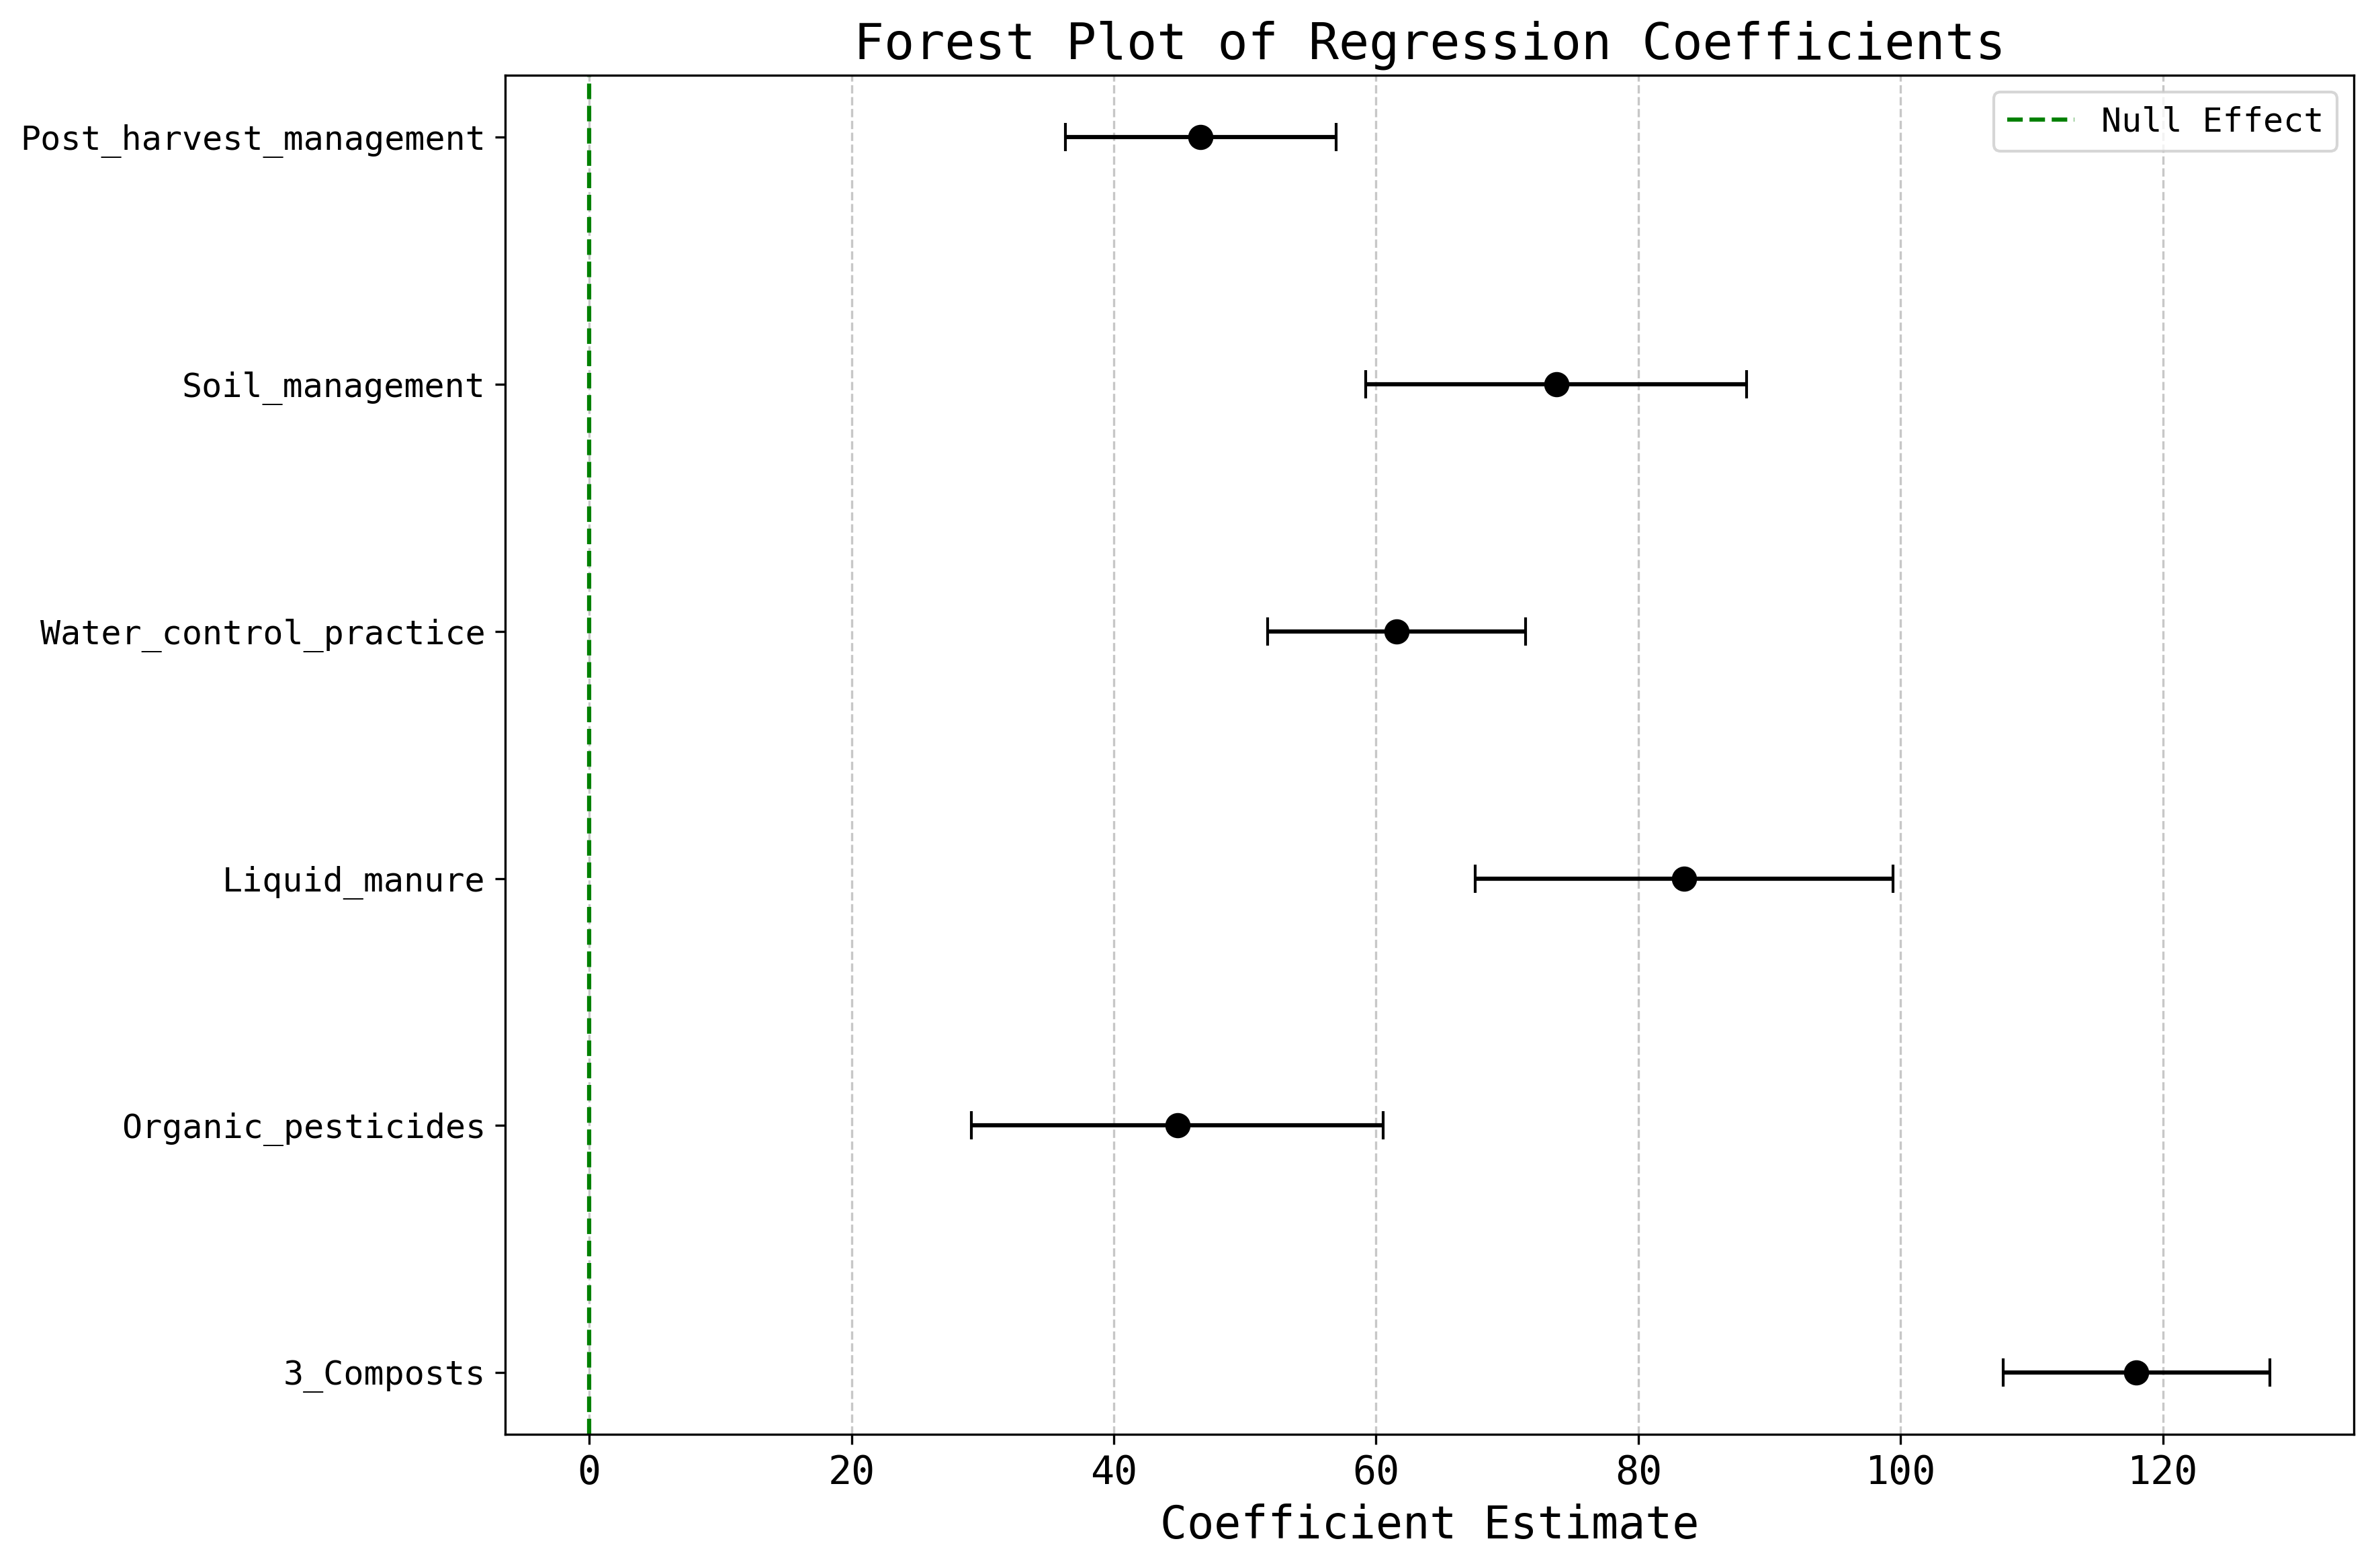

In [56]:
from matplotlib import rcParams
import matplotlib.pyplot as plt

# Set font to Oswald
rcParams['font.family'] = 'monospace'
rcParams['font.size'] = 14  # Increase default font size

# Extract coefficients and confidence intervals
coefficients_ = results_.params
conf_intervals_ = results_.conf_int()
conf_intervals_['coef'] = coefficients_

# Rename columns for clarity
conf_intervals_.columns = ['CI_lower', 'CI_upper', 'coef']

# Prepare the plot with increased DPI
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)  # Increase figure size and DPI

# Calculate error bars for the confidence intervals
lower_errors_ = conf_intervals_['coef'][1:] - conf_intervals_['CI_lower'][1:]
upper_errors_ = conf_intervals_['CI_upper'][1:] - conf_intervals_['coef'][1:]

# Plot coefficients with error bars
ax.errorbar(conf_intervals_['coef'][1:], 
            np.arange(len(variables)), 
            xerr=[lower_errors_, upper_errors_], 
            fmt='o', color='black', capsize=5, markersize=8)

# Add a reference line at x=0 (null effect)
ax.axvline(x=0, color='green', linestyle='--', label='Null Effect')

# Set y-ticks and labels
ax.set_yticks(np.arange(len(variables)))
ax.set_yticklabels(variables, fontsize=12)  # Increase font size for y-tick labels
ax.set_xlabel('Coefficient Estimate', fontsize=16)  # Increase font size for x-label
ax.set_title('Forest Plot of Regression Coefficients', fontsize=18)  # Increase font size for title
ax.grid(axis='x', linestyle='--', alpha=0.7)  # Add grid lines for better readability
ax.legend(fontsize=12)  # Increase font size for legend

# Optimize layout and display the plot
plt.tight_layout()
plt.show()


In [57]:
conf_intervals_.sort_values(by='coef', ascending=False)

,CI_lower,CI_upper,coef
const,340.077762761,366.637126828,353.357444794
3_Composts,107.805854954,128.151629567,117.978742260
Liquid_manure,67.580887887,99.398256320,83.489572103
Soil_management,59.230561005,88.233657040,73.732109022
Water_control_practice,51.752078048,71.394318632,61.573198340
Post_harvest_management,36.287662689,56.948212976,46.617937832
Organic_pesticides,29.161444951,60.556817456,44.859131204


## Standardized

In [58]:
y_standardized = (y - y.mean()) / y.std()
X = sm.add_constant(X)

model = sm.OLS(y_standardized, X)
results = model.fit()

print(results.summary())

                                    OLS Regression Results                                   
Dep. Variable:     Agriculture Value (USD_Cons_rate)   R-squared:                       0.154
Model:                                           OLS   Adj. R-squared:                  0.154
Method:                                Least Squares   F-statistic:                     469.8
Date:                               Tue, 04 Nov 2025   Prob (F-statistic):               0.00
Time:                                       15:31:53   Log-Likelihood:                -20661.
No. Observations:                              15474   AIC:                         4.134e+04
Df Residuals:                                  15467   BIC:                         4.139e+04
Df Model:                                          6                                         
Covariance Type:                           nonrobust                                         
                              coef    std err          t    

In [59]:
print(results.params)

const                     -0.653831554
3_Composts                 0.374011967
Organic_pesticides         0.142210805
Liquid_manure              0.264675640
Water_control_practice     0.195197140
Soil_management            0.233742881
Post_harvest_management    0.147786511
dtype: float64


In [60]:
print(results.conf_int())

                                   0            1
const                   -0.695930325 -0.611732784
3_Composts               0.341762246  0.406261689
Organic_pesticides       0.092446564  0.191975046
Liquid_manure            0.214242501  0.315108779
Water_control_practice   0.164062577  0.226331702
Soil_management          0.187770595  0.279715167
Post_harvest_management  0.115037844  0.180535177


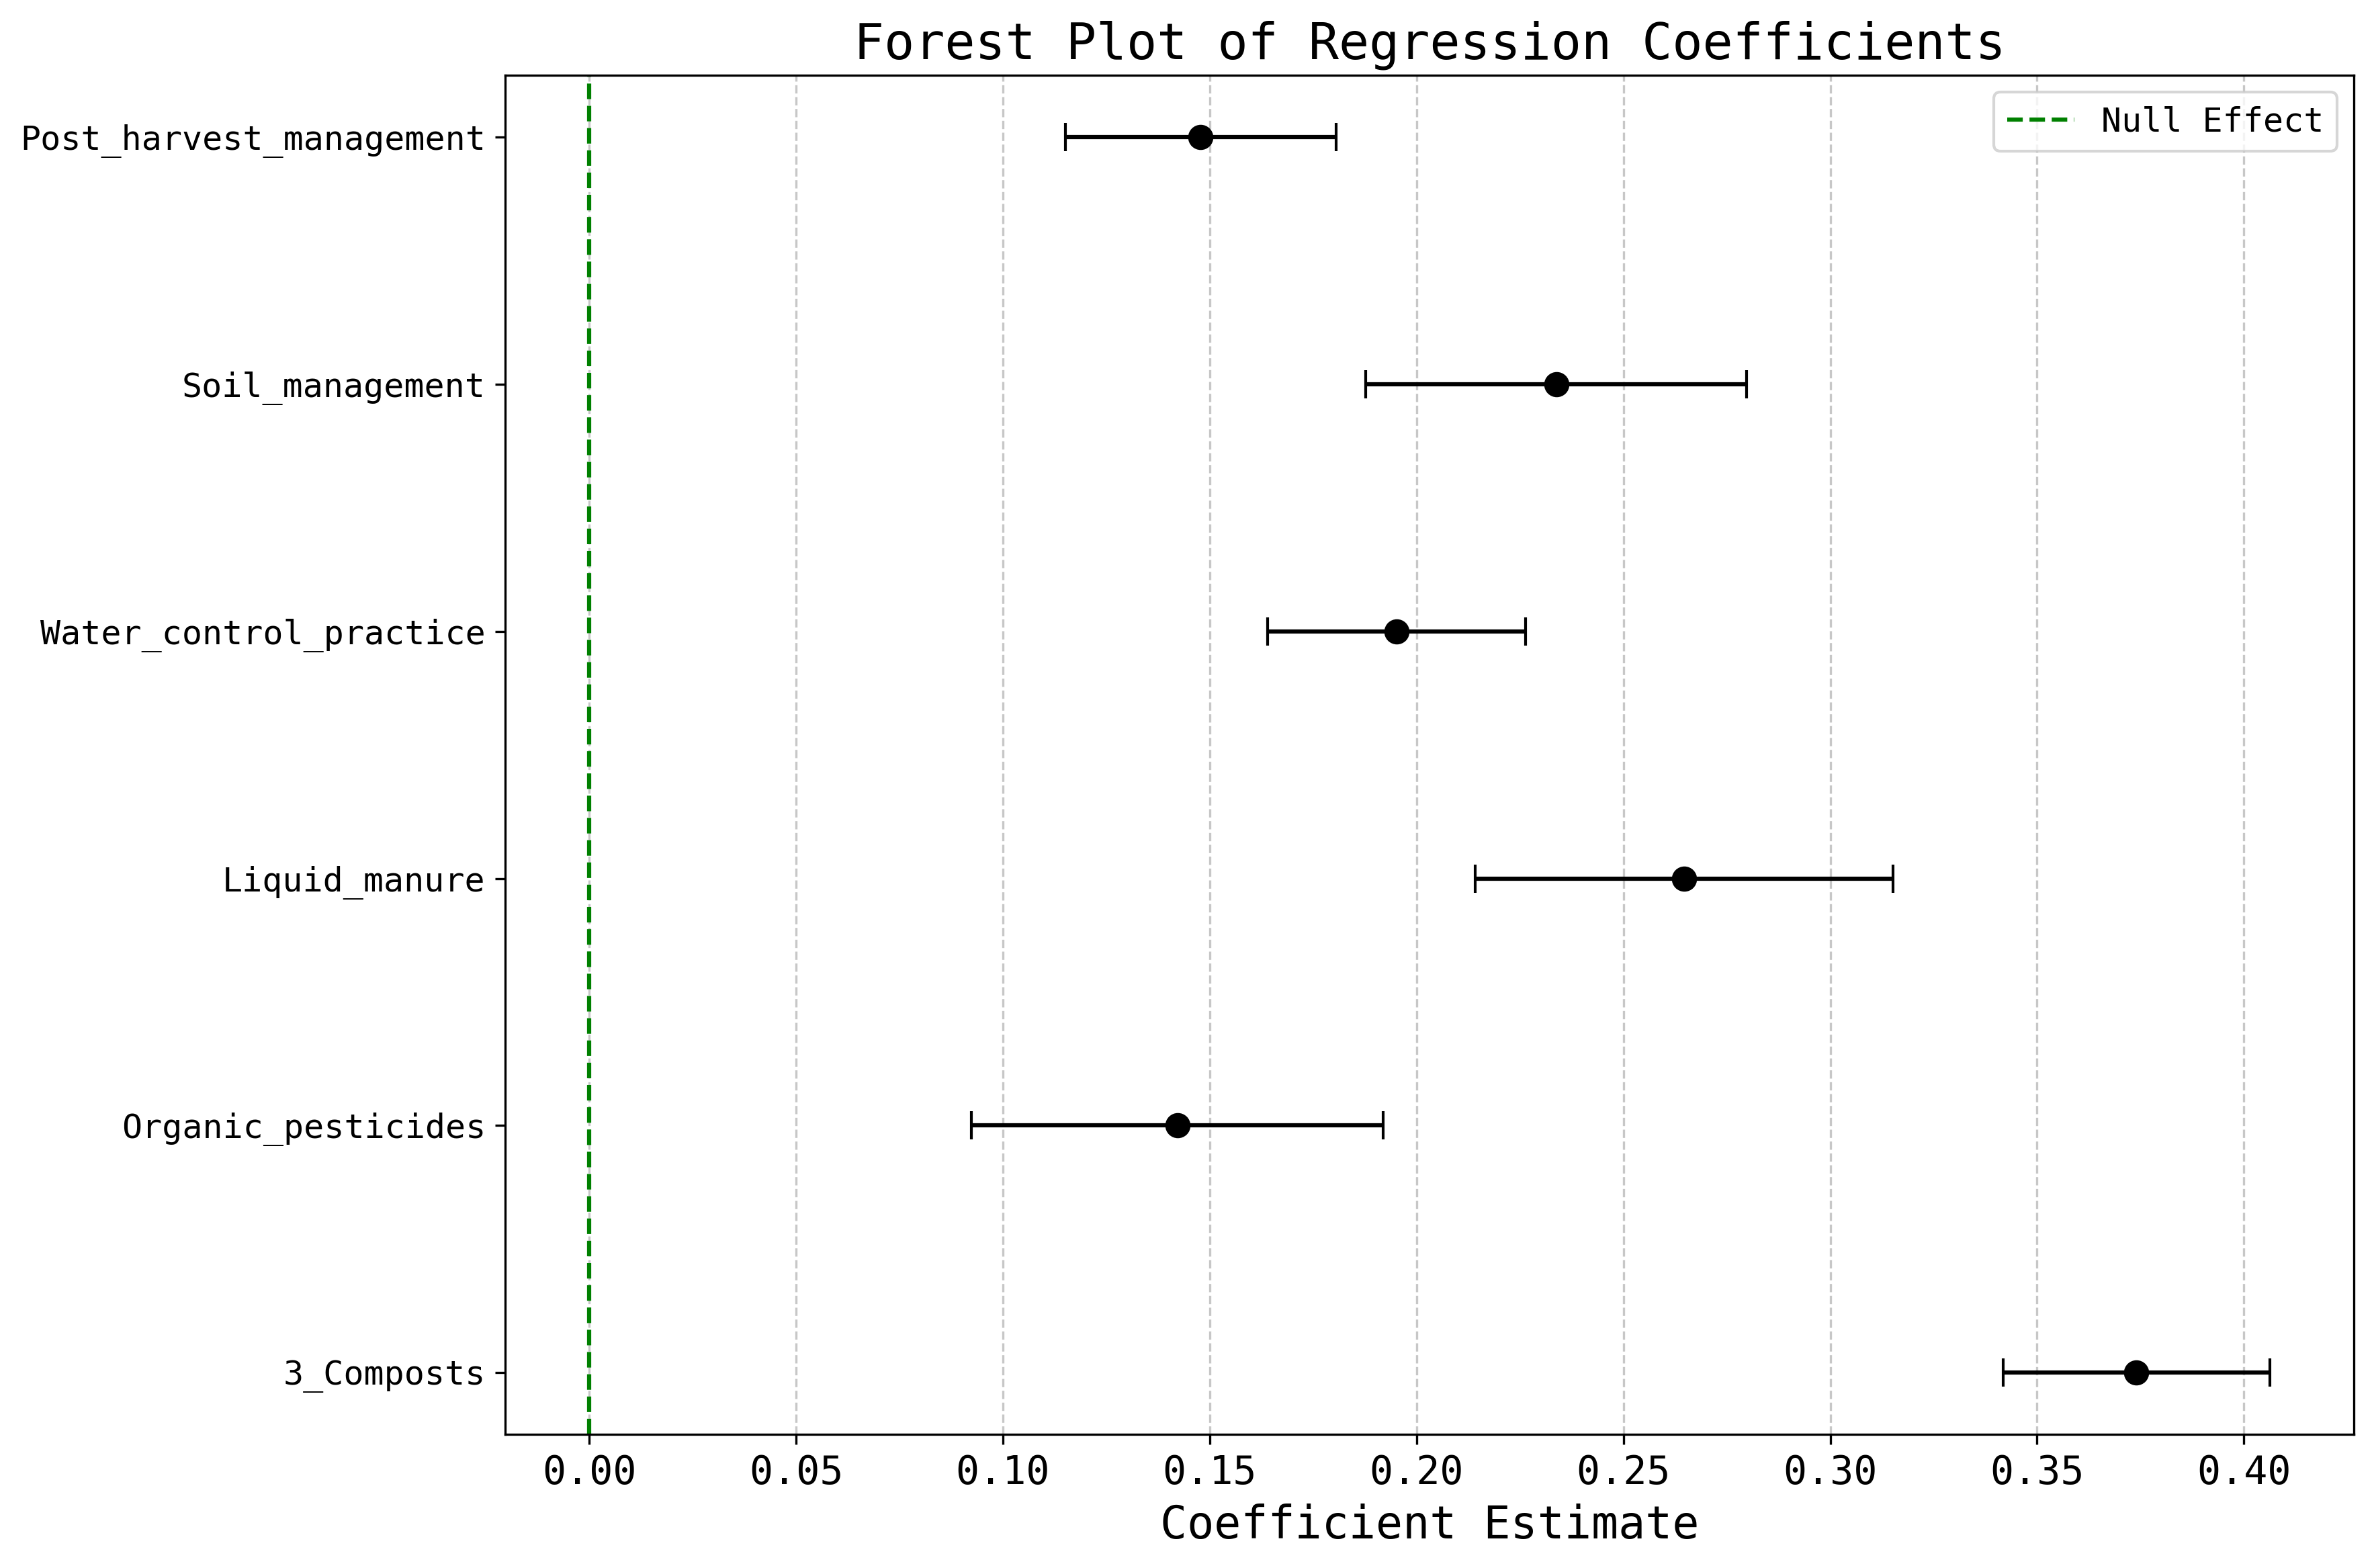

In [61]:
from matplotlib import rcParams
import matplotlib.pyplot as plt

# Set font to Oswald
rcParams['font.family'] = 'monospace'
rcParams['font.size'] = 14  # Increase default font size

# Extract coefficients and confidence intervals
coefficients = results.params
conf_intervals = results.conf_int()
conf_intervals['coef'] = coefficients

# Rename columns for clarity
conf_intervals.columns = ['CI_lower', 'CI_upper', 'coef']

# Prepare the plot with increased DPI
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)  # Increase figure size and DPI

# Calculate error bars for the confidence intervals
lower_errors = conf_intervals['coef'][1:] - conf_intervals['CI_lower'][1:]
upper_errors = conf_intervals['CI_upper'][1:] - conf_intervals['coef'][1:]

# Plot coefficients with error bars
ax.errorbar(conf_intervals['coef'][1:], 
            np.arange(len(variables)), 
            xerr=[lower_errors, upper_errors], 
            fmt='o', color='black', capsize=5, markersize=8)

# Add a reference line at x=0 (null effect)
ax.axvline(x=0, color='green', linestyle='--', label='Null Effect')

# Set y-ticks and labels
ax.set_yticks(np.arange(len(variables)))
ax.set_yticklabels(variables, fontsize=12)  # Increase font size for y-tick labels
ax.set_xlabel('Coefficient Estimate', fontsize=16)  # Increase font size for x-label
ax.set_title('Forest Plot of Regression Coefficients', fontsize=18)  # Increase font size for title
ax.grid(axis='x', linestyle='--', alpha=0.7)  # Add grid lines for better readability
ax.legend(fontsize=12)  # Increase font size for legend

# Optimize layout and display the plot
plt.tight_layout()
plt.show()


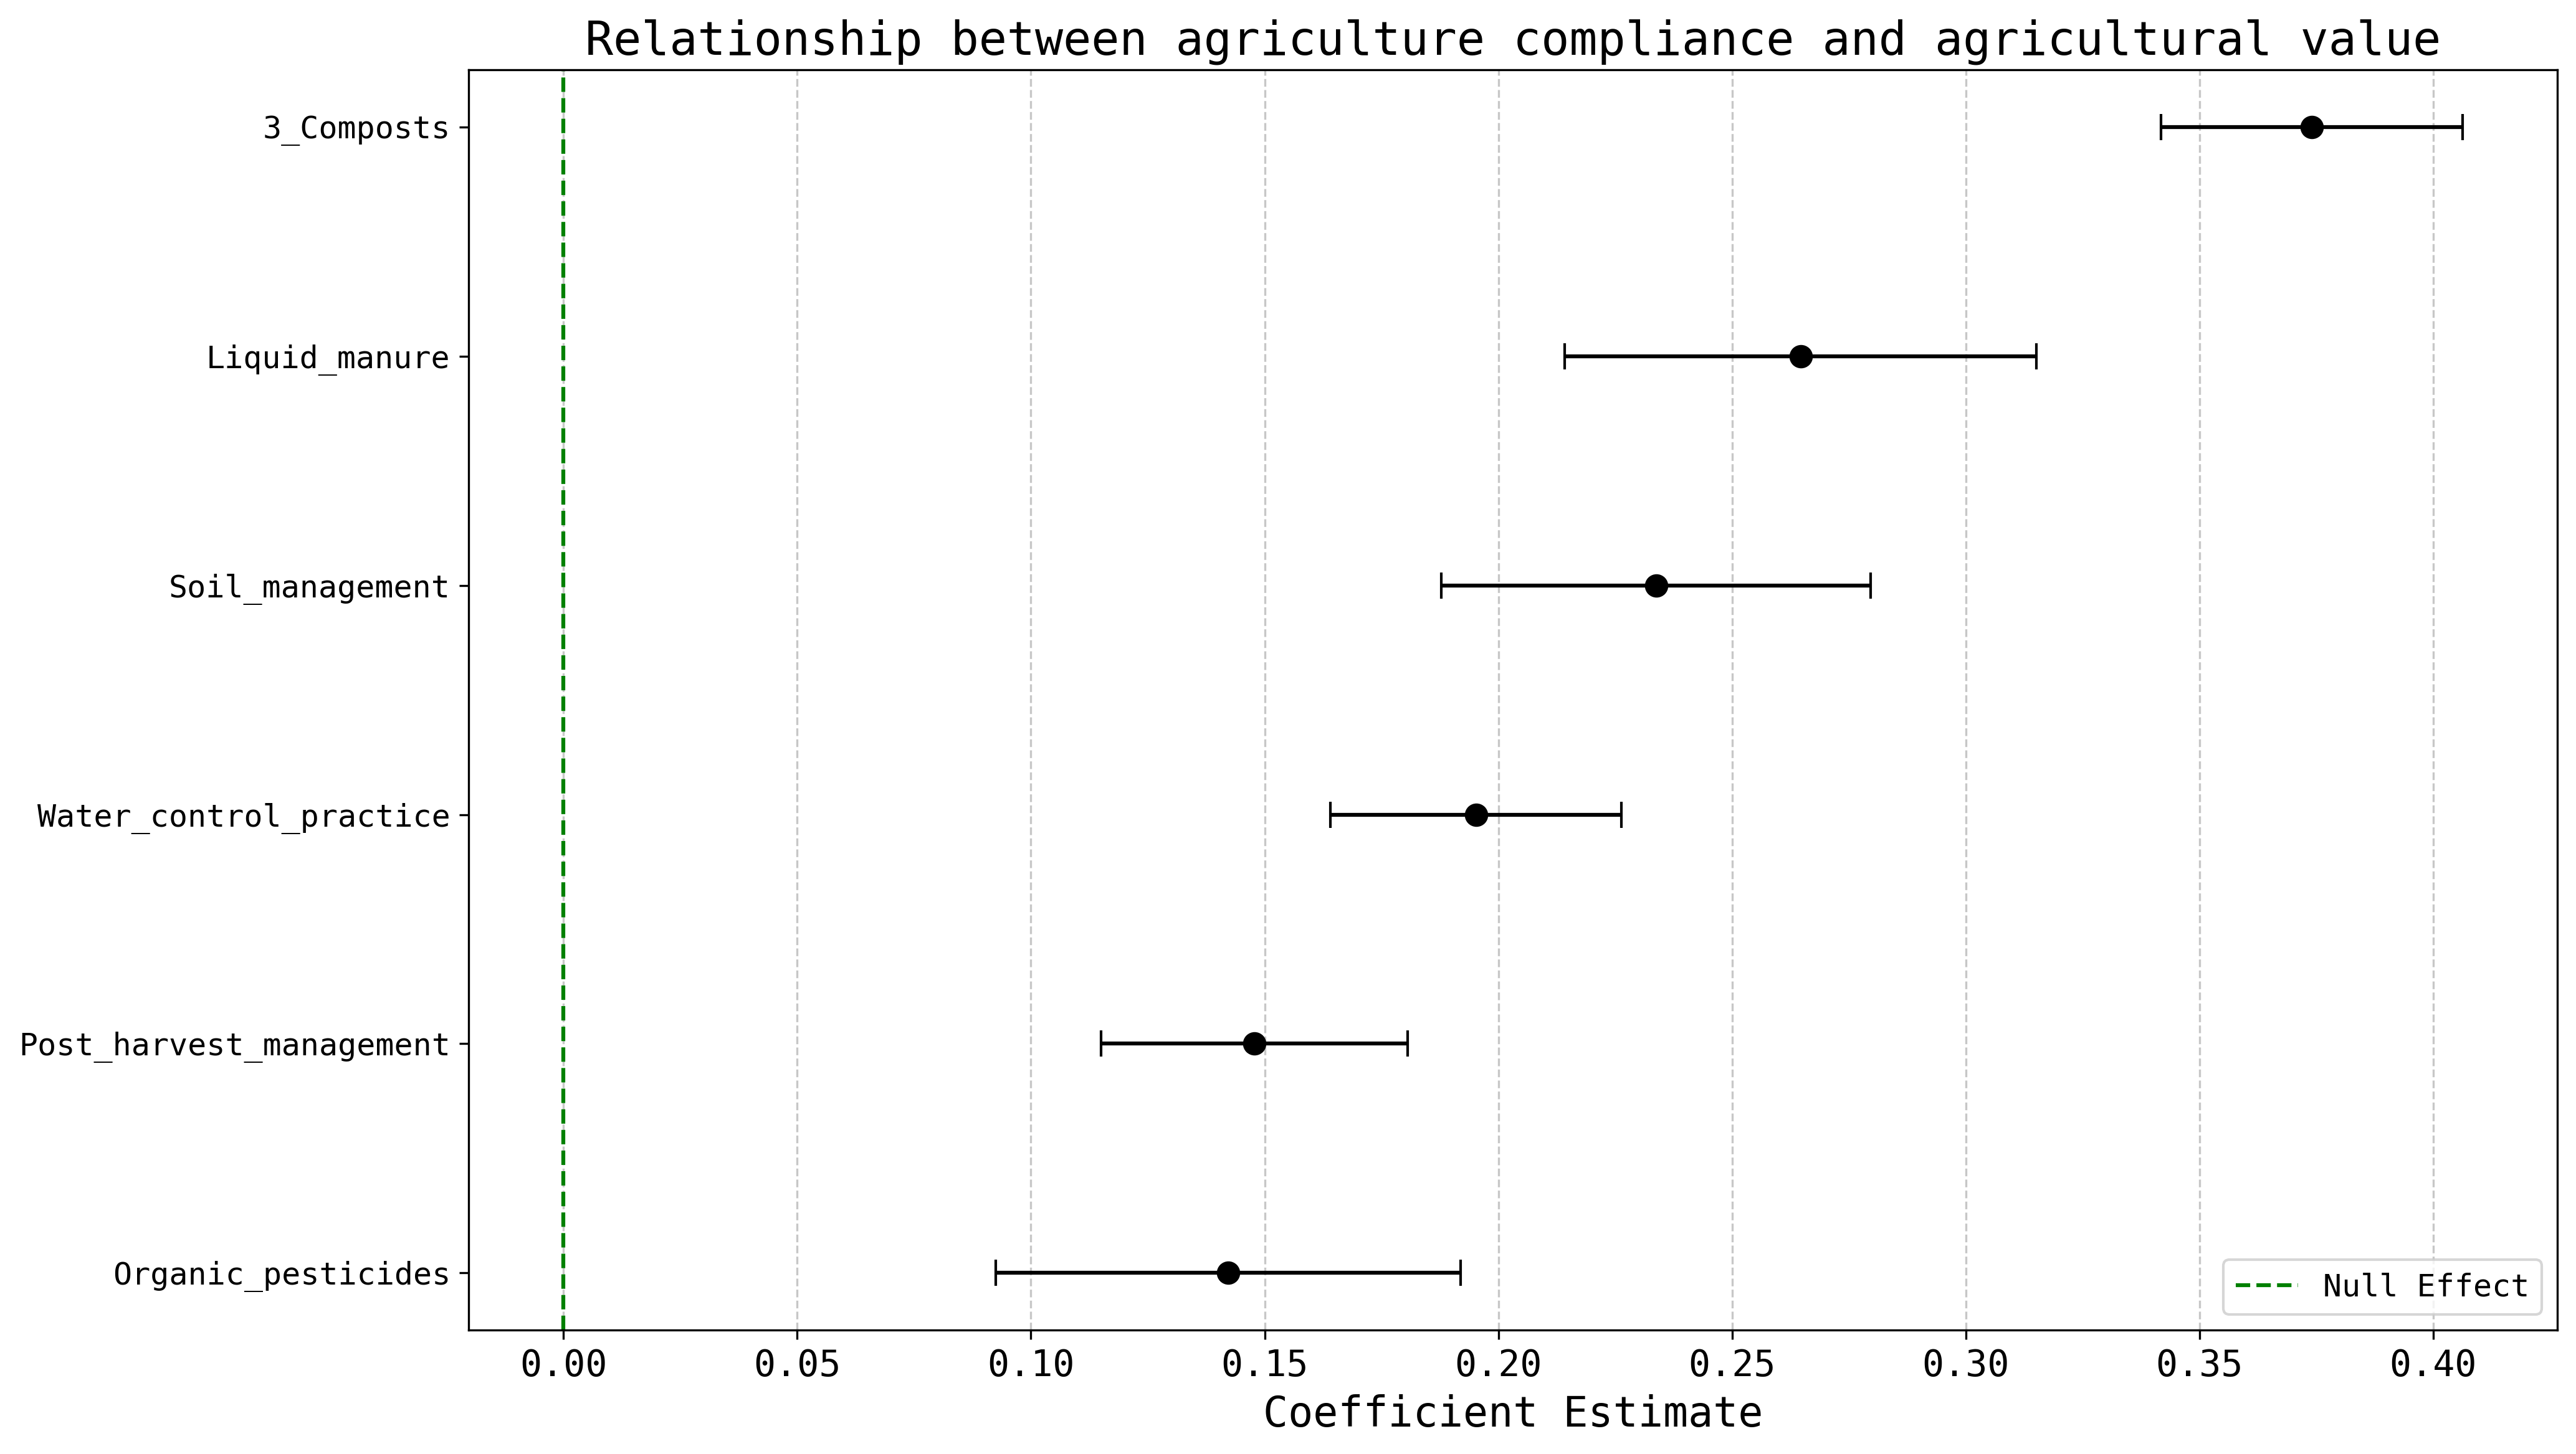

In [62]:
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np

# Set font to Oswald
rcParams['font.family'] = 'monospace'
rcParams['font.size'] = 14  # Increase default font size

# Extract coefficients and confidence intervals
coefficients = results.params
conf_intervals = results.conf_int()
conf_intervals['coef'] = coefficients

# Rename columns for clarity
conf_intervals.columns = ['CI_lower', 'CI_upper', 'coef']

# Sort the DataFrame by the 'coef' column, excluding the constant
conf_intervals_sorted = conf_intervals.iloc[1:].sort_values('coef', ascending=True)

# Prepare the plot with increased DPI
fig, ax = plt.subplots(figsize=(14, 8), dpi=300)  # Increase figure size and DPI

# Calculate error bars for the confidence intervals
lower_errors = conf_intervals_sorted['coef'] - conf_intervals_sorted['CI_lower']
upper_errors = conf_intervals_sorted['CI_upper'] - conf_intervals_sorted['coef']

# Plot coefficients with error bars
ax.errorbar(conf_intervals_sorted['coef'], 
            np.arange(len(conf_intervals_sorted)), 
            xerr=[lower_errors, upper_errors], 
            fmt='o', color='black', capsize=5, markersize=8)

# Add a reference line at x=0 (null effect)
ax.axvline(x=0, color='green', linestyle='--', label='Null Effect')

# Set y-ticks and labels
ax.set_yticks(np.arange(len(conf_intervals_sorted)))
ax.set_yticklabels(conf_intervals_sorted.index, fontsize=12)  # Increase font size for y-tick labels

ax.set_xlabel('Coefficient Estimate', fontsize=16)  # Increase font size for x-label
ax.set_title('Relationship between agriculture compliance and agricultural value', fontsize=18)  # Increase font size for title
ax.grid(axis='x', linestyle='--', alpha=0.7)  # Add grid lines for better readability
ax.legend(fontsize=12)  # Increase font size for legend

# Optimize layout and display the plot
plt.tight_layout()
plt.savefig("forest_plot_c_i.png")
plt.show()

In [63]:
conf_intervals_sorted.sort_values(by='coef', ascending=False)

,CI_lower,CI_upper,coef
3_Composts,0.341762246,0.406261689,0.374011967
Liquid_manure,0.214242501,0.315108779,0.264675640
Soil_management,0.187770595,0.279715167,0.233742881
Water_control_practice,0.164062577,0.226331702,0.195197140
Post_harvest_management,0.115037844,0.180535177,0.147786511
Organic_pesticides,0.092446564,0.191975046,0.142210805


breakdown by region:


REGION: Mid_West
                                    OLS Regression Results                                   
Dep. Variable:     Agriculture Value (USD_Cons_rate)   R-squared:                       0.170
Model:                                           OLS   Adj. R-squared:                  0.170
Method:                                Least Squares   F-statistic:                     189.7
Date:                               Tue, 04 Nov 2025   Prob (F-statistic):          1.66e-220
Time:                                       15:32:54   Log-Likelihood:                -7352.0
No. Observations:                               5547   AIC:                         1.472e+04
Df Residuals:                                   5540   BIC:                         1.476e+04
Df Model:                                          6                                         
Covariance Type:                           nonrobust                                         
                              coef    std 

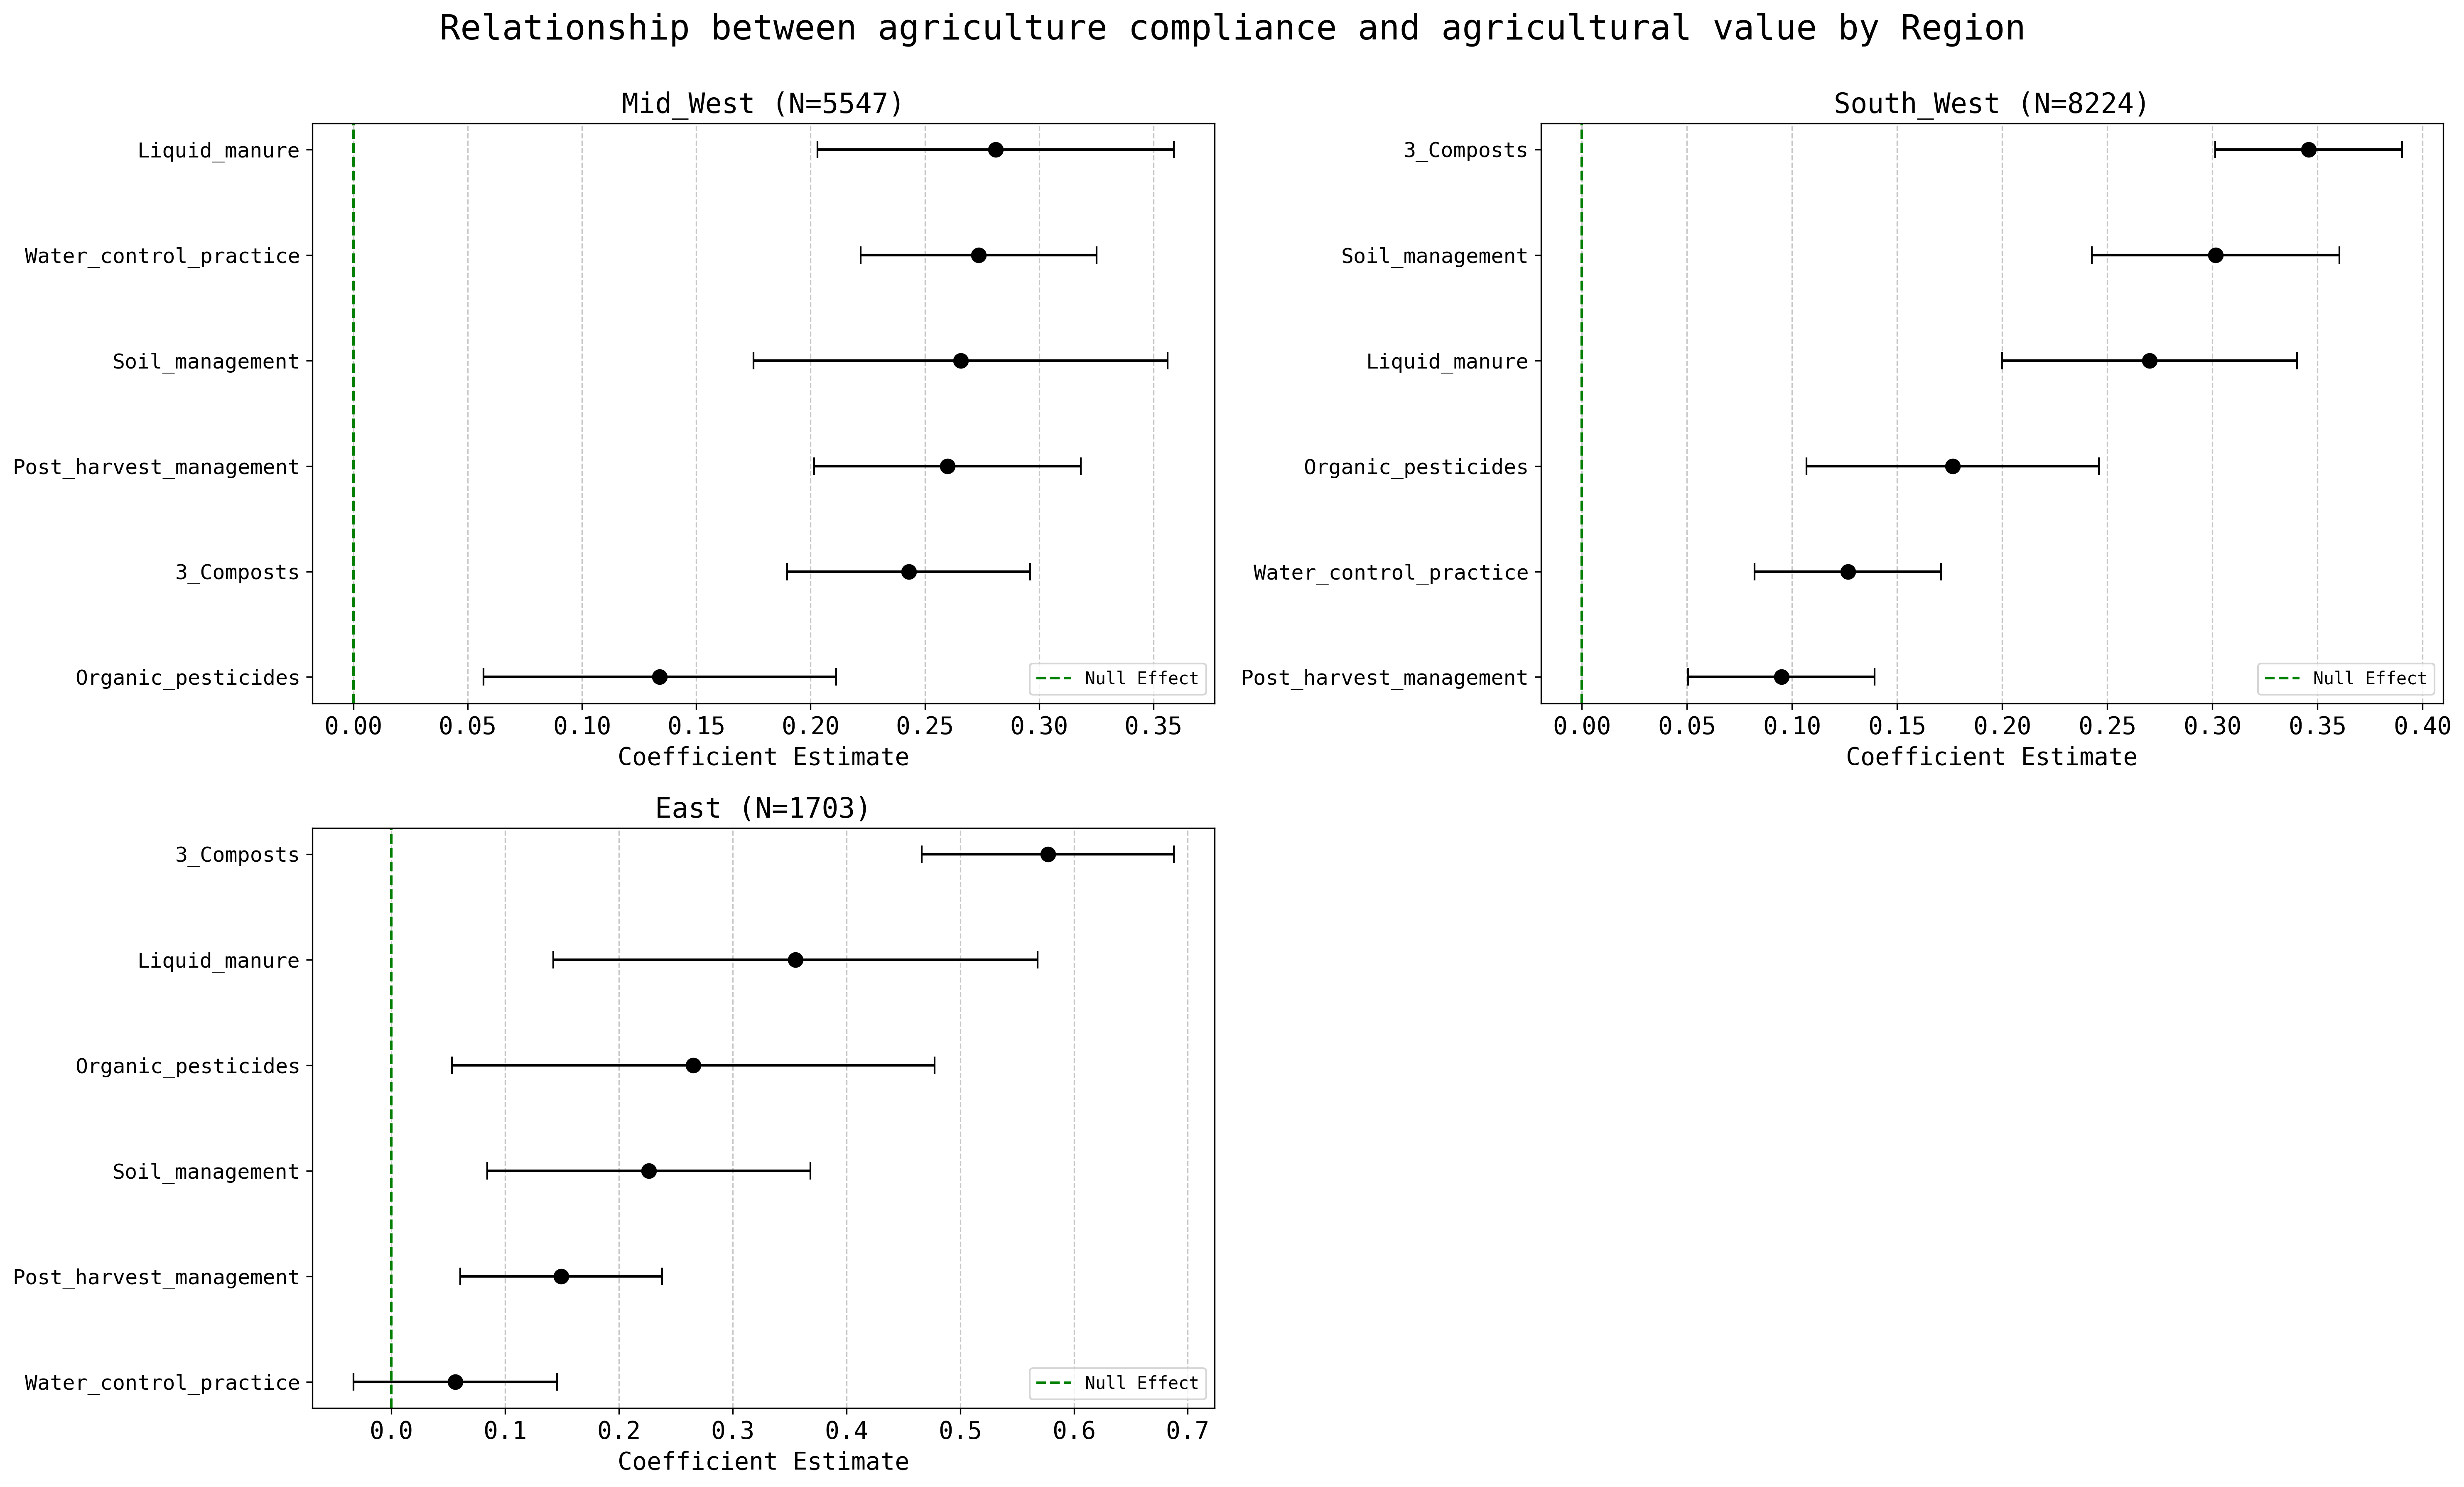

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from matplotlib import rcParams

# Set font to monospace
rcParams['font.family'] = 'monospace'
rcParams['font.size'] = 14

# Get unique regions
regions = df['region'].unique()

# Create subplots - adjust layout based on number of regions
n_regions = len(regions)
n_cols = 2  # Two columns of plots
n_rows = int(np.ceil(n_regions / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6*n_rows), dpi=300)
axes = axes.flatten() if n_regions > 1 else [axes]  # Ensure axes is iterable

# Loop through each region
for idx, region in enumerate(regions):
    # Filter data for this region
    df_region = df[df['region'] == region]
    
    # Prepare data
    X = df_region[variables]
    y = df_region['Agriculture Value (USD_Cons_rate)']
    
    # Check if we have enough data
    if len(df_region) < len(variables) + 2:
        axes[idx].text(0.5, 0.5, f'Insufficient data for {region}', 
                      ha='center', va='center', fontsize=14)
        axes[idx].set_title(f'{region} (N={len(df_region)})', fontsize=18)
        continue
    
    # Standardize y
    y_standardized = (y - y.mean()) / y.std()
    
    # Add constant and fit model
    X_const = sm.add_constant(X)
    model = sm.OLS(y_standardized, X_const)
    results = model.fit()
    
    # Extract coefficients and confidence intervals
    coefficients = results.params
    conf_intervals = results.conf_int()
    conf_intervals['coef'] = coefficients
    conf_intervals.columns = ['CI_lower', 'CI_upper', 'coef']
    
    # Sort by coefficient, excluding constant
    conf_intervals_sorted = conf_intervals.iloc[1:].sort_values('coef', ascending=True)
    
    # Calculate error bars
    lower_errors = conf_intervals_sorted['coef'] - conf_intervals_sorted['CI_lower']
    upper_errors = conf_intervals_sorted['CI_upper'] - conf_intervals_sorted['coef']
    
    # Plot on the appropriate subplot
    ax = axes[idx]
    ax.errorbar(conf_intervals_sorted['coef'], 
                np.arange(len(conf_intervals_sorted)), 
                xerr=[lower_errors, upper_errors], 
                fmt='o', color='black', capsize=5, markersize=8)
    
    # Add reference line at x=0
    ax.axvline(x=0, color='green', linestyle='--', label='Null Effect')
    
    # Set labels and title
    ax.set_yticks(np.arange(len(conf_intervals_sorted)))
    ax.set_yticklabels(conf_intervals_sorted.index, fontsize=12)
    ax.set_xlabel('Coefficient Estimate', fontsize=14)
    ax.set_title(f'{region} (N={len(df_region)})', fontsize=16)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    ax.legend(fontsize=10)
    
    # Print summary for this region
    print(f"\n{'='*60}")
    print(f"REGION: {region}")
    print(f"{'='*60}")
    print(results.summary())

# Hide any unused subplots
for idx in range(n_regions, len(axes)):
    axes[idx].axis('off')

# Add overall title
fig.suptitle('Relationship between agriculture compliance and agricultural value by Region', 
             fontsize=20, y=0.995)

plt.tight_layout()
plt.savefig("forest_plot_by_region.png", bbox_inches='tight')
plt.show()

In [ ]:
for region in regions:
    df_region = df[df['region'] == region]
    # ... (rest of the regression code)
    
    fig, ax = plt.subplots(figsize=(14, 8), dpi=300)
    # ... (rest of the plotting code)
    
    plt.savefig(f"forest_plot_{region}.png")
    plt.show()

In [80]:
# import matplotlib.pyplot as plt
# import numpy as np
# import statsmodels.api as sm
# from matplotlib import rcParams

# # Set font to monospace
# rcParams['font.family'] = 'monospace'
# rcParams['font.size'] = 14

# # Get unique regions
# regions = df['region'].unique()

# # Store results for the combined plot
# all_results = []

# # Create subplots - adjust layout based on number of regions
# n_regions = len(regions)
# n_cols = 2  # Two columns of plots
# n_rows = int(np.ceil(n_regions / n_cols))

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6*n_rows), dpi=300)
# axes = axes.flatten() if n_regions > 1 else [axes]  # Ensure axes is iterable

# # Loop through each region
# for idx, region in enumerate(regions):
#     # Filter data for this region
#     df_region = df[df['region'] == region]
    
#     # Prepare data
#     X = df_region[variables]
#     y = df_region['Agriculture Value (USD_Cons_rate)']
    
#     # Check if we have enough data
#     if len(df_region) < len(variables) + 2:
#         axes[idx].text(0.5, 0.5, f'Insufficient data for {region}', 
#                       ha='center', va='center', fontsize=14)
#         axes[idx].set_title(f'{region} (N={len(df_region)})', fontsize=18)
#         continue
    
#     # Standardize y
#     y_standardized = (y - y.mean()) / y.std()
    
#     # Add constant and fit model
#     X_const = sm.add_constant(X)
#     model = sm.OLS(y_standardized, X_const)
#     results = model.fit()
    
#     # Extract coefficients and confidence intervals
#     coefficients = results.params
#     conf_intervals = results.conf_int()
#     conf_intervals['coef'] = coefficients
#     conf_intervals.columns = ['CI_lower', 'CI_upper', 'coef']
    
#     # Sort by coefficient, excluding constant
#     conf_intervals_sorted = conf_intervals.iloc[1:].sort_values('coef', ascending=True)
    
#     # Store for combined plot
#     all_results.append({
#         'region': region,
#         'data': conf_intervals_sorted,
#         'n': len(df_region)
#     })
    
#     # Calculate error bars
#     lower_errors = conf_intervals_sorted['coef'] - conf_intervals_sorted['CI_lower']
#     upper_errors = conf_intervals_sorted['CI_upper'] - conf_intervals_sorted['coef']
    
#     # Plot on the appropriate subplot
#     ax = axes[idx]
#     ax.errorbar(conf_intervals_sorted['coef'], 
#                 np.arange(len(conf_intervals_sorted)), 
#                 xerr=[lower_errors, upper_errors], 
#                 fmt='o', color='black', capsize=5, markersize=8)
    
#     # Add reference line at x=0
#     ax.axvline(x=0, color='green', linestyle='--', label='Null Effect')
    
#     # Set labels and title
#     ax.set_yticks(np.arange(len(conf_intervals_sorted)))
#     ax.set_yticklabels(conf_intervals_sorted.index, fontsize=12)
#     ax.set_xlabel('Coefficient Estimate', fontsize=14)
#     ax.set_title(f'{region} (N={len(df_region)})', fontsize=16)
#     ax.grid(axis='x', linestyle='--', alpha=0.7)
#     ax.legend(fontsize=10)
    
#     # Print summary for this region
#     print(f"\n{'='*60}")
#     print(f"REGION: {region}")
#     print(f"{'='*60}")
#     print(results.summary())

# # Hide any unused subplots
# for idx in range(n_regions, len(axes)):
#     axes[idx].axis('off')

# # Add overall title
# fig.suptitle('Relationship between agriculture compliance and agricultural value by Region', 
#              fontsize=20, y=0.995)

# plt.tight_layout()
# # plt.savefig("forest_plot_by_region.png", bbox_inches='tight')
# plt.show()

# # ============================================================================
# # NEW: Create combined plot with all regions in different colors
# # ============================================================================

# # Get all unique variables across regions
# all_variables = set()
# for result in all_results:
#     all_variables.update(result['data'].index)
# all_variables = sorted(list(all_variables))

# # Define colors for each region
# colors = plt.cm.tab10(np.linspace(0, 1, len(all_results)))

# # Create figure
# fig_combined, ax_combined = plt.subplots(figsize=(14, max(10, len(all_variables) * 1.5)), dpi=300)

# # Calculate spacing for variables
# n_vars = len(all_variables)
# spacing_between_vars = 1.0
# spacing_between_regions = 0.15
# total_regions = len(all_results)
# region_offset = np.linspace(-(total_regions-1)*spacing_between_regions/2, 
#                             (total_regions-1)*spacing_between_regions/2, 
#                             total_regions)

# # Plot each region
# for region_idx, result in enumerate(all_results):
#     region = result['region']
#     conf_intervals_sorted = result['data']
#     n = result['n']
#     color = colors[region_idx]
    
#     # For each variable in this region
#     for var_name, row in conf_intervals_sorted.iterrows():
#         var_position = all_variables.index(var_name)
#         y_position = var_position * spacing_between_vars + region_offset[region_idx]  # FIXED THIS LINE
        
#         coef = row['coef']
#         ci_lower = row['CI_lower']
#         ci_upper = row['CI_upper']
        
#         # Plot point and error bar
#         ax_combined.errorbar(coef, y_position,
#                            xerr=[[coef - ci_lower], [ci_upper - coef]],
#                            fmt='o', color=color, capsize=5, markersize=8,
#                            label=f'{region} (N={n})' if var_name == conf_intervals_sorted.index[0] else '',
#                            alpha=0.8)